# Imports

In [1]:
"""cifar10 main: interactive notebook experiment.

Interactive CIFAR10 baseline and continual-learning workflow using imported repository
helpers. Cells load images or stored features, construct a classifier, fit/evaluate it,
and invoke continually_learn with the experiment settings shown inline.

Inputs are dataset/model paths, selected classes, preprocessing, optimizer, callback,
training, and replay options in the cells. Outputs are models, histories, plots,
continual accuracy trajectories, and files written by the invoked helpers. These
exploratory calls retain their written API signatures; importing init changes working
directory and initializes the notebook runtime.

Executing training cells mutates weights and kernel state. Opening this file does not
run them; earlier setup cells supply names used by later cells.
"""

import os


os.chdir("../")

In [2]:
from model import get_model, get_callbacks
from dataloader import load_cifar10
from learner import continually_learn
from common.utils import (hyperas_path, init, CL_plot, 
                        plot_history, extract_features, 
                        show_img, save_samples, load_samples)


TUNED_CNN_MODEL_PATH = os.path.join(hyperas_path, "cifar10_cnn_model_01.h5")
TUNED_DNN_MODEL_PATH = os.path.join(hyperas_path, "cifar10_dnn_model_00.h5")

CLASS_NUM = 10
BATCH_SIZE = 128
EPOCHS = 100

init()

# Demonstrating the usual 10-class training setting

## Hyperparameter-tuned CNN Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(preprocess="min-max")

(40000, 32, 32, 3) (40000, 1)
(10000, 32, 32, 3) (10000, 1)
(10000, 32, 32, 3) (10000, 1)
---0
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---1
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---2
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]



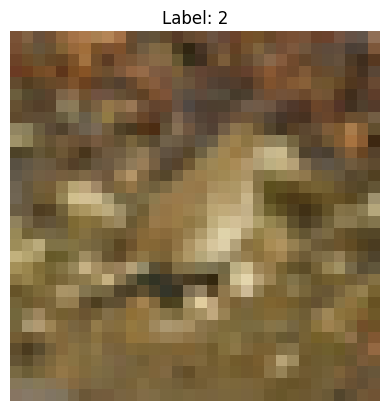

In [12]:
index = 1_000
show_img(x_train[index], y_train[index])

In [13]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_CNN_MODEL_PATH) # , use_loaded_opt=True

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (None, 16, 16, 64)        9664      
                                                                 
 sequential_7 (Sequential)   (None, 8, 8, 128)         222208    
                                                                 
 sequential_8 (Sequential)   (None, 4, 4, 128)         295936    
                                                                 
 sequential_9 (Sequential)   (None, 2, 2, 256)         295936    
                                                                 
 global_average_pooling2d_1   (None, 256)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                        

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 11s 23ms/step - loss: 1.4033 - accuracy: 0.4966 - val_loss: 2.6316 - val_accuracy: 0.2719
Epoch 2/100
313/313 [==============================] - 7s 21ms/step - loss: 0.9531 - accuracy: 0.6611 - val_loss: 1.5426 - val_accuracy: 0.5000
Epoch 3/100
313/313 [==============================] - 7s 21ms/step - loss: 0.7570 - accuracy: 0.7338 - val_loss: 1.0097 - val_accuracy: 0.6537
Epoch 4/100
313/313 [==============================] - 7s 21ms/step - loss: 0.6215 - accuracy: 0.7837 - val_loss: 0.9815 - val_accuracy: 0.6718
Epoch 5/100
313/313 [==============================] - 7s 21ms/step - loss: 0.5252 - accuracy: 0.8175 - val_loss: 0.9472 - val_accuracy: 0.6873
Epoch 6/100
313/313 [==============================] - 7s 21ms/step - loss: 0.4368 - accuracy: 0.8478 - val_loss: 0.9513 - val_accuracy: 0.6909
Epoch 7/100
313/313 [==============================] - 7s 21ms/step - loss: 0.3714 - accuracy: 0.8706 - val_loss: 1.0242 - val_accuracy

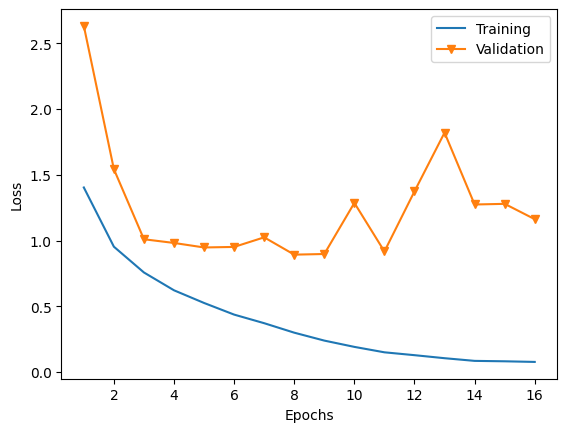

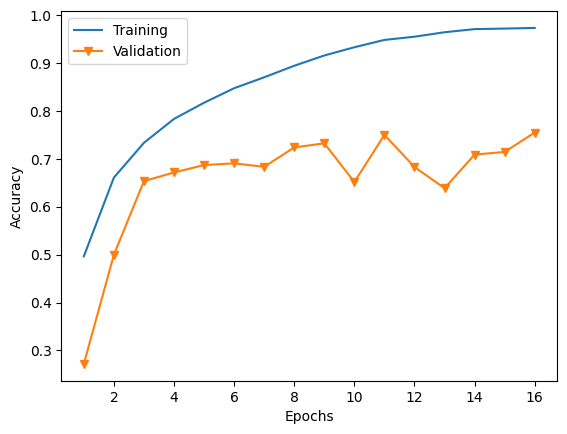

313/313 [==============================] - 1s 4ms/step - loss: 0.9191 - accuracy: 0.7528


[0.9191192388534546, 0.7527999877929688]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

## Hyperparameter-tuned DNN Model

In [3]:
feature_train, y_train, feature_val, y_val, feature_test, y_test = load_cifar10(return_features=True, verbose=0)

In [4]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_DNN_MODEL_PATH, use_loaded_opt=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_353 (Ba  (None, 2048)             8192      
 tchNormalization)                                               
                                                                 
 sequential_336 (Sequential)  (None, 256)              525312    
                                                                 
 sequential_337 (Sequential)  (None, 128)              33280     
                                                                 
 dropout_488 (Dropout)       (None, 128)               0         
                                                                 
 dense (Dense)               (None, 10)                1290      
                                                                 
Total params: 568,074
Trainable params: 563,210
Non-trainable params: 4,864
______________________________________________

In [5]:
history = model.fit(
    feature_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 5s 10ms/step - loss: 0.4893 - accuracy: 0.8389 - val_loss: 0.3627 - val_accuracy: 0.8747
Epoch 2/100
313/313 [==============================] - 3s 10ms/step - loss: 0.3550 - accuracy: 0.8787 - val_loss: 0.3196 - val_accuracy: 0.8918
Epoch 3/100
313/313 [==============================] - 3s 11ms/step - loss: 0.2999 - accuracy: 0.8974 - val_loss: 0.3151 - val_accuracy: 0.8954
Epoch 4/100
313/313 [==============================] - 3s 11ms/step - loss: 0.2633 - accuracy: 0.9109 - val_loss: 0.3165 - val_accuracy: 0.8979
Epoch 5/100
313/313 [==============================] - 3s 11ms/step - loss: 0.2351 - accuracy: 0.9194 - val_loss: 0.3166 - val_accuracy: 0.8984
Epoch 6/100
313/313 [==============================] - 3s 10ms/step - loss: 0.2150 - accuracy: 0.9262 - val_loss: 0.3081 - val_accuracy: 0.9009
Epoch 7/100
313/313 [==============================] - 3s 10ms/step - loss: 0.1921 - accuracy: 0.9342 - val_loss: 0.3170 - val_accuracy:

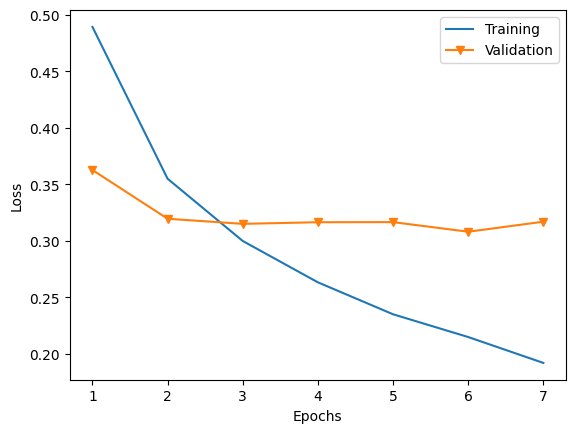

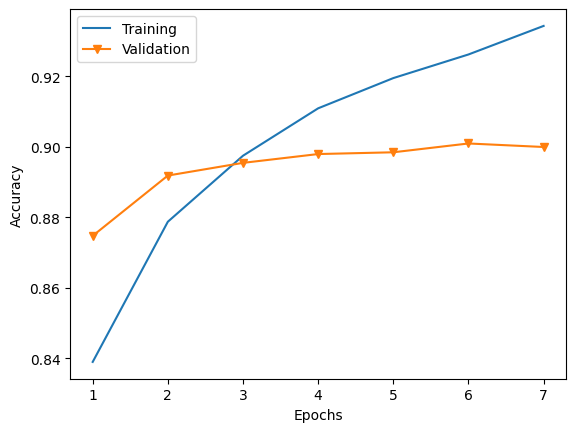

313/313 [==============================] - 1s 3ms/step - loss: 0.3341 - accuracy: 0.8890


[0.33412042260169983, 0.8889999985694885]

In [6]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Transfer Learning with the pre-trained Xception Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(verbose=0)

In [12]:
feature_train, feature_val, feature_test = extract_features(
    [x_train, x_val, x_test], 
    batch_size=BATCH_SIZE, 
    file_name="./data/cifar10_xception_gavgpooled_features_train_val_test"
)

79/79 [==============================] - 73s 940ms/step


In [ ]:
feature_train, feature_val, feature_test = load_samples(
    "./data/cifar10_xception_gavgpooled_features_train_val_test", 
    ".npy"
)

In [13]:
model = get_model(CLASS_NUM, model_type="DNN", dropout_rate=0.5)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 2048)              0         
                                                                 
 dense_1 (Dense)             (None, 10)                20490     
                                                                 
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
_________________________________________________________________


In [14]:
history = model.fit(
    feature_train, y_train,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
1250/1250 [==============================] - 5s 3ms/step - loss: 0.5361 - accuracy: 0.8285 - val_loss: 0.3863 - val_accuracy: 0.8721
Epoch 2/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3932 - accuracy: 0.8654 - val_loss: 0.3503 - val_accuracy: 0.8823
Epoch 3/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3732 - accuracy: 0.8723 - val_loss: 0.3413 - val_accuracy: 0.8801
Epoch 4/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3636 - accuracy: 0.8747 - val_loss: 0.3416 - val_accuracy: 0.8793
Epoch 5/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3554 - accuracy: 0.8781 - val_loss: 0.3305 - val_accuracy: 0.8827
Epoch 6/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3528 - accuracy: 0.8779 - val_loss: 0.3327 - val_accuracy: 0.8833
Epoch 7/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3501 - accuracy: 0.8789 - val_loss: 0.3277 - val_ac

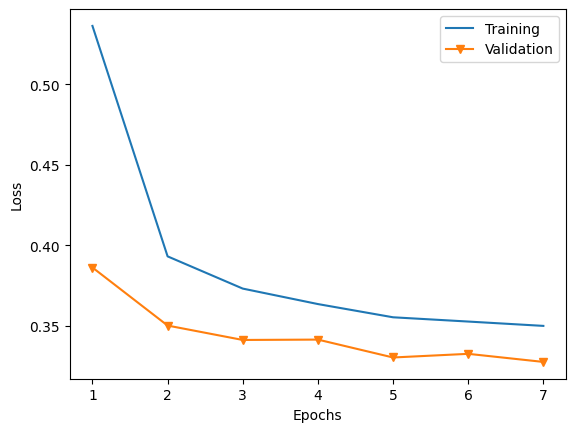

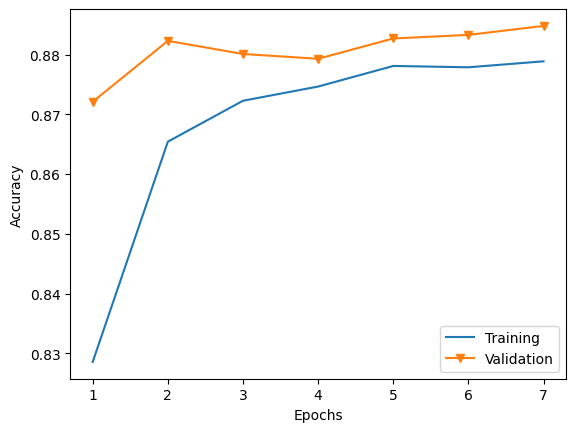

313/313 [==============================] - 1s 3ms/step - loss: 0.3587 - accuracy: 0.8788


[0.35869887471199036, 0.8787999749183655]

In [15]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Fine-tuning the pre-trained Xception Model

In [9]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(verbose=0)

In [12]:
model = get_model(CLASS_NUM, model_type="pretrained", num_last_not_frozen=12, dropout_rate=0.50)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resize (Lambda)             (None, 299, 299, 3)       0         
                                                                 
 xception_preprocess (Lambda  (None, 299, 299, 3)      0         
 )                                                               
                                                                 
 xception (Functional)       (None, 10, 10, 2048)      20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 10)                2

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 804s 3s/step - loss: 0.3157 - accuracy: 0.8951 - val_loss: 0.2794 - val_accuracy: 0.9133
Epoch 2/100
313/313 [==============================] - 833s 3s/step - loss: 0.1676 - accuracy: 0.9423 - val_loss: 0.2581 - val_accuracy: 0.9157
Epoch 3/100
313/313 [==============================] - 666s 2s/step - loss: 0.1059 - accuracy: 0.9624 - val_loss: 0.2893 - val_accuracy: 0.9163
Epoch 4/100
313/313 [==============================] - 495s 2s/step - loss: 0.0650 - accuracy: 0.9777 - val_loss: 0.3214 - val_accuracy: 0.9159
Epoch 5/100
313/313 [==============================] - 828s 3s/step - loss: 0.0417 - accuracy: 0.9857 - val_loss: 0.2883 - val_accuracy: 0.9222
Epoch 6/100
313/313 [==============================] - 871s 3s/step - loss: 0.0360 - accuracy: 0.9877 - val_loss: 0.3195 - val_accuracy: 0.9259
Epoch 7/100
313/313 [==============================] - 681s 2s/step - loss: 0.0318 - accuracy: 0.9886 - val_loss: 0.3426 - val_accuracy:

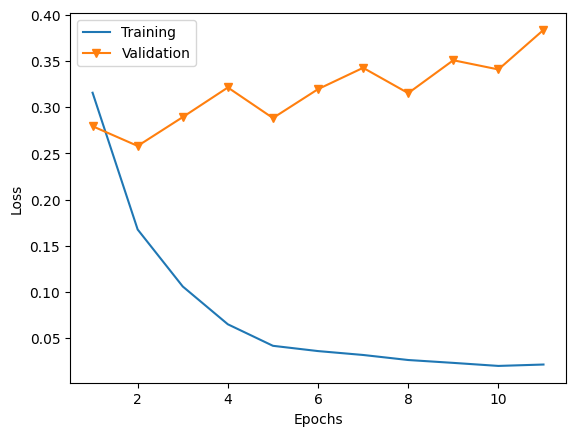

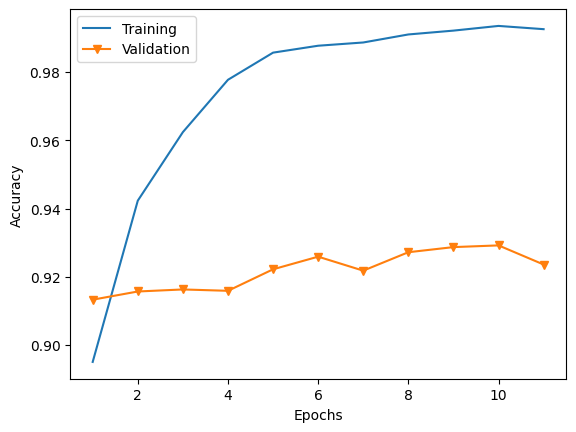

313/313 [==============================] - 159s 488ms/step - loss: 0.3389 - accuracy: 0.9225


[0.338937371969223, 0.9225000143051147]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

# Continual Learning

## Continually adding classes to different models

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 8.
Epoch 13: early stopping


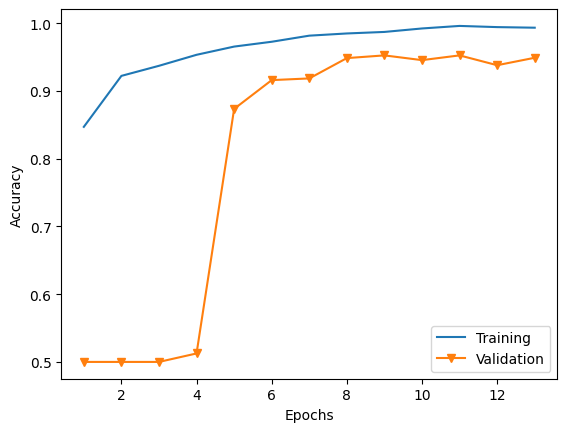

63/63 [==============================] - 0s 4ms/step
              precision    recall  f1-score   support

           0     0.9734    0.9160    0.9438      1000
           1     0.9207    0.9750    0.9471      1000

    accuracy                         0.9455      2000
   macro avg     0.9471    0.9455    0.9455      2000
weighted avg     0.9471    0.9455    0.9455      2000



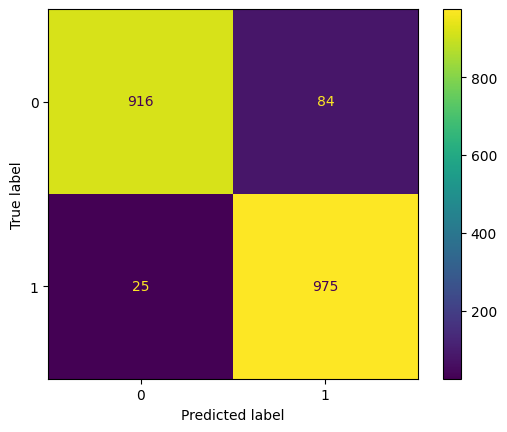

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


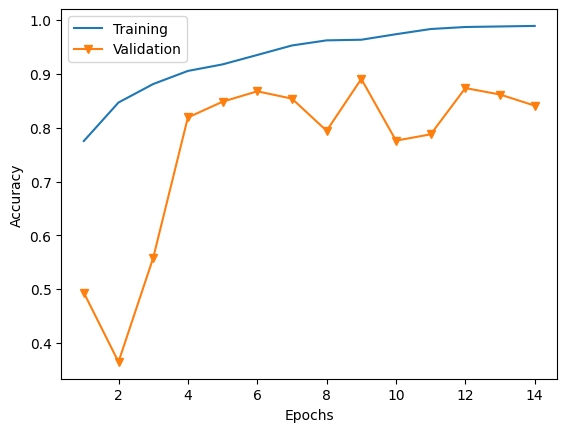

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.8442    0.8940    0.8684      1000
           1     0.9348    0.9600    0.9472      1000
           2     0.9168    0.8380    0.8757      1000

    accuracy                         0.8973      3000
   macro avg     0.8986    0.8973    0.8971      3000
weighted avg     0.8986    0.8973    0.8971      3000



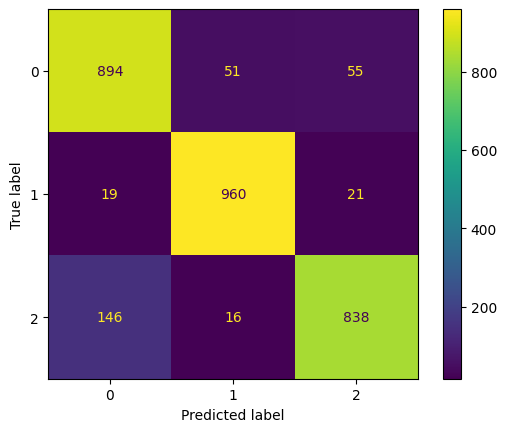

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


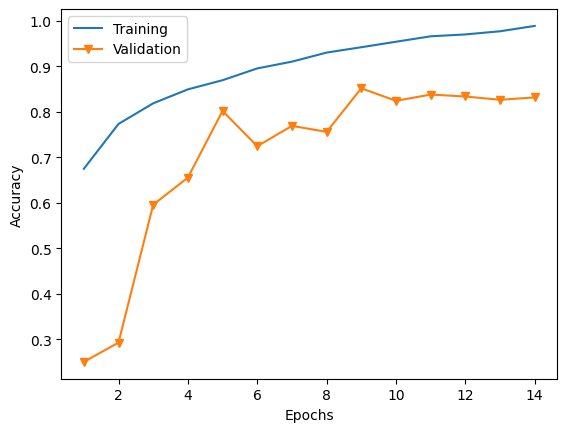

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8934    0.8380    0.8648      1000
           1     0.8724    0.9780    0.9222      1000
           2     0.8348    0.7530    0.7918      1000
           3     0.7950    0.8260    0.8102      1000

    accuracy                         0.8488      4000
   macro avg     0.8489    0.8488    0.8473      4000
weighted avg     0.8489    0.8488    0.8473      4000



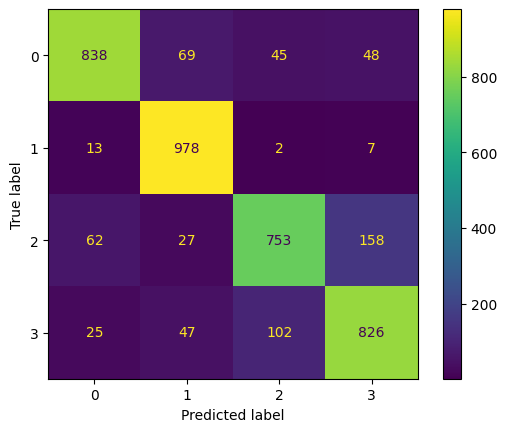

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 8.
Epoch 13: early stopping


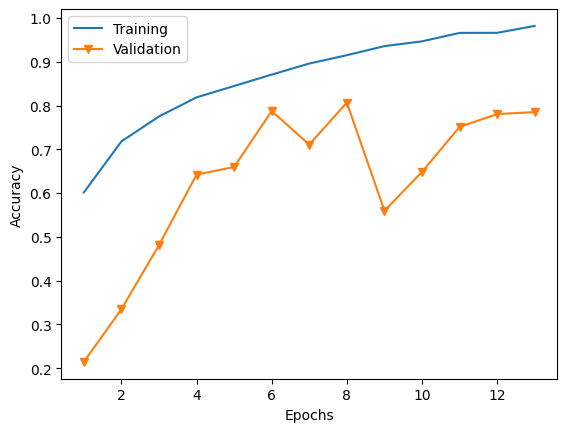

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8122    0.9040    0.8557      1000
           1     0.8994    0.9660    0.9315      1000
           2     0.6875    0.7590    0.7215      1000
           3     0.9003    0.5330    0.6696      1000
           4     0.7386    0.8250    0.7794      1000

    accuracy                         0.7974      5000
   macro avg     0.8076    0.7974    0.7915      5000
weighted avg     0.8076    0.7974    0.7915      5000



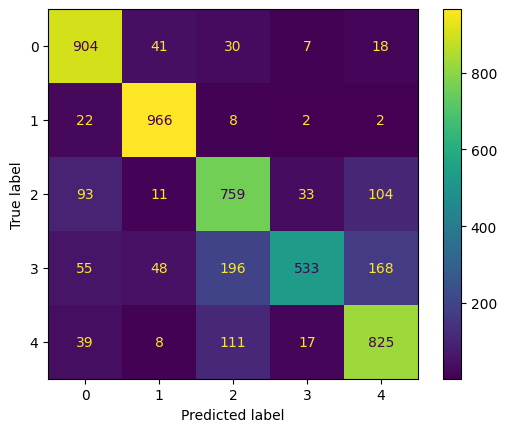

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 18.
Epoch 23: early stopping


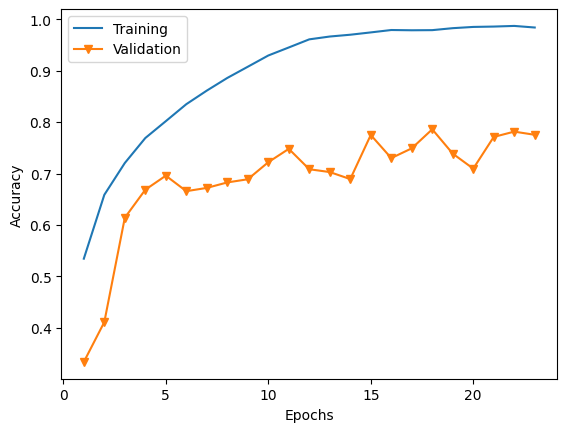

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8808    0.8500    0.8651      1000
           1     0.9706    0.9260    0.9478      1000
           2     0.7786    0.7070    0.7411      1000
           3     0.6600    0.6580    0.6590      1000
           4     0.7839    0.7980    0.7909      1000
           5     0.6675    0.7730    0.7164      1000

    accuracy                         0.7853      6000
   macro avg     0.7903    0.7853    0.7867      6000
weighted avg     0.7903    0.7853    0.7867      6000



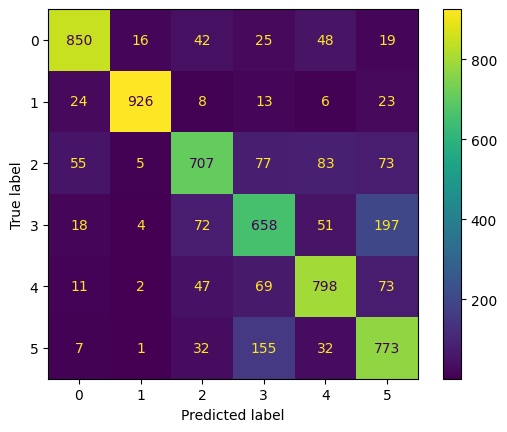

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 12.
Epoch 17: early stopping


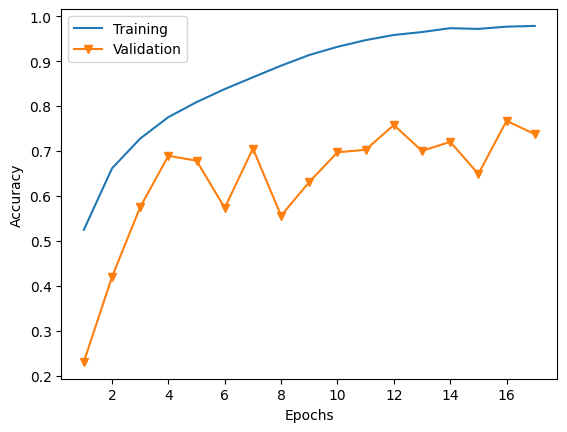

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8544    0.8450    0.8497      1000
           1     0.8727    0.9670    0.9175      1000
           2     0.7430    0.6620    0.7002      1000
           3     0.5473    0.7410    0.6296      1000
           4     0.6938    0.8450    0.7619      1000
           5     0.9065    0.4170    0.5712      1000
           6     0.8357    0.8190    0.8273      1000

    accuracy                         0.7566      7000
   macro avg     0.7791    0.7566    0.7510      7000
weighted avg     0.7791    0.7566    0.7510      7000



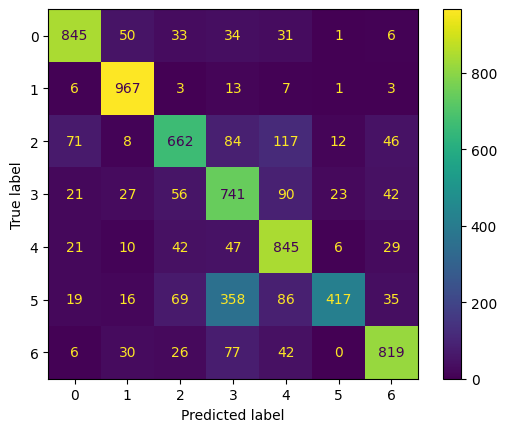

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


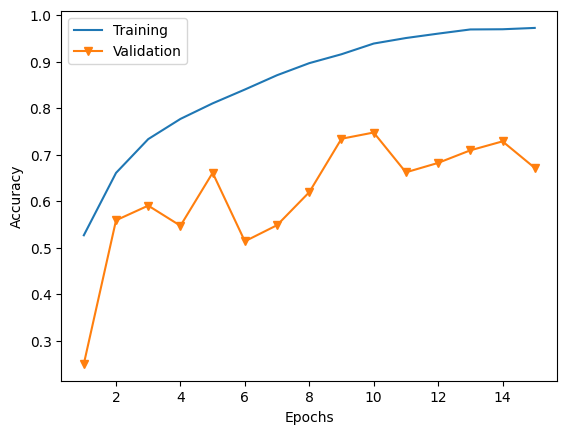

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.7849    0.8940    0.8359      1000
           1     0.9646    0.9000    0.9312      1000
           2     0.7560    0.6350    0.6902      1000
           3     0.5924    0.6540    0.6217      1000
           4     0.5265    0.9030    0.6652      1000
           5     0.8944    0.3980    0.5509      1000
           6     0.8335    0.8110    0.8221      1000
           7     0.8508    0.7240    0.7823      1000

    accuracy                         0.7399      8000
   macro avg     0.7754    0.7399    0.7374      8000
weighted avg     0.7754    0.7399    0.7374      8000



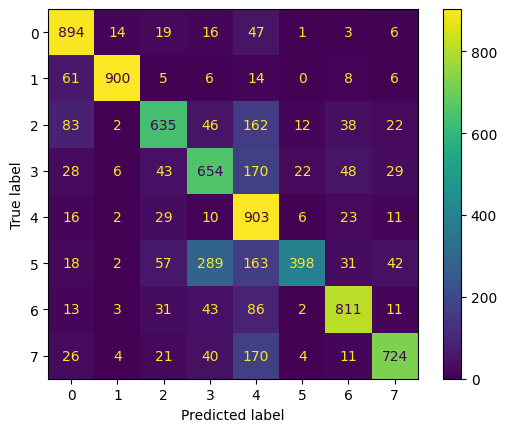

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 12.
Epoch 17: early stopping


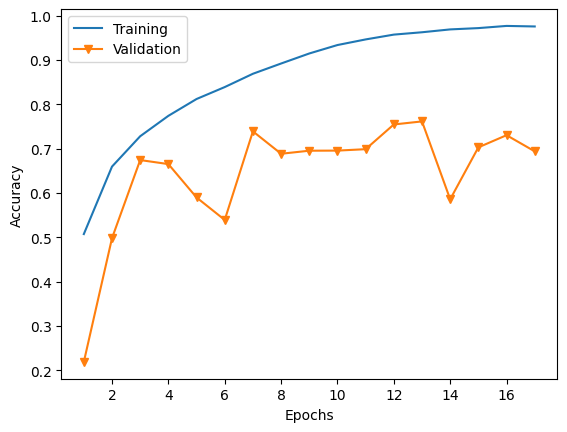

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.7832    0.8200    0.8012      1000
           1     0.8299    0.9560    0.8885      1000
           2     0.6919    0.6400    0.6649      1000
           3     0.7491    0.4060    0.5266      1000
           4     0.5614    0.8820    0.6861      1000
           5     0.7284    0.6410    0.6819      1000
           6     0.9010    0.7280    0.8053      1000
           7     0.7372    0.8190    0.7759      1000
           8     0.8631    0.8320    0.8473      1000

    accuracy                         0.7471      9000
   macro avg     0.7606    0.7471    0.7420      9000
weighted avg     0.7606    0.7471    0.7420      9000



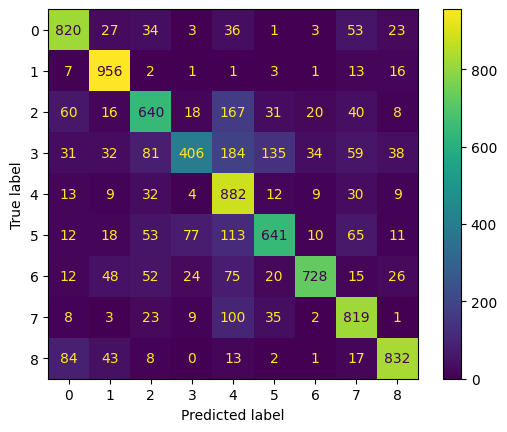

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 7.
Epoch 12: early stopping


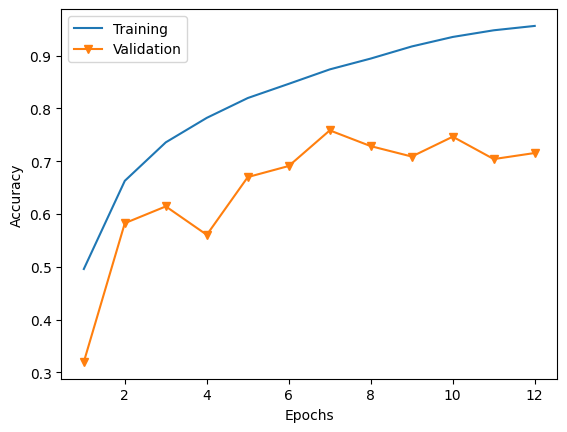

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.6634    0.8710    0.7531      1000
           1     0.8807    0.8640    0.8723      1000
           2     0.7178    0.6740    0.6952      1000
           3     0.6473    0.5580    0.5994      1000
           4     0.6125    0.7730    0.6835      1000
           5     0.7561    0.6510    0.6996      1000
           6     0.9671    0.5290    0.6839      1000
           7     0.7109    0.8680    0.7816      1000
           8     0.8222    0.9020    0.8603      1000
           9     0.8800    0.8070    0.8419      1000

    accuracy                         0.7497     10000
   macro avg     0.7658    0.7497    0.7471     10000
weighted avg     0.7658    0.7497    0.7471     10000



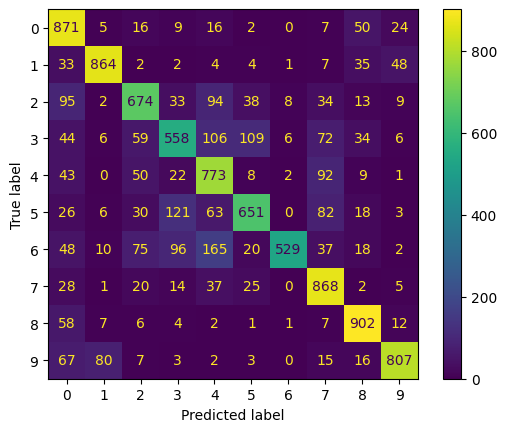

---------------------------------------------------------------------------



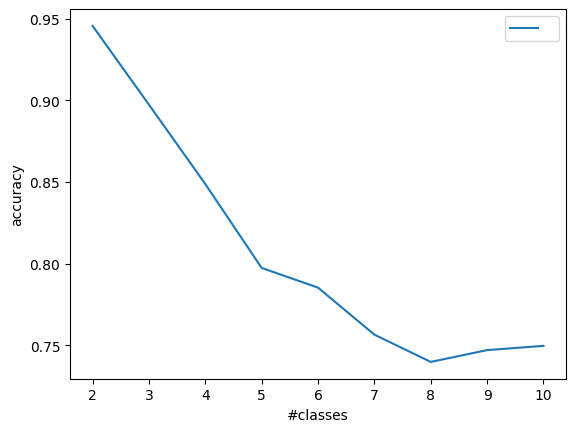

In [4]:
acc_list1 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    load_dataset_fn_kwargs={"preprocess": "min-max"},
    remove_prev_classes=False, 
    keep_same_model=False, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS, 
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


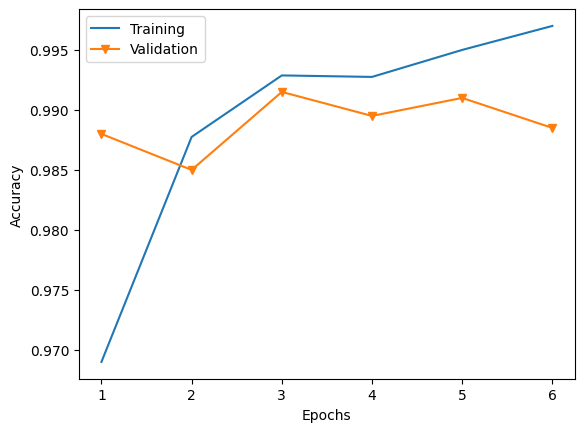

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9909    0.9850    0.9880      1000
           1     0.9851    0.9910    0.9880      1000

    accuracy                         0.9880      2000
   macro avg     0.9880    0.9880    0.9880      2000
weighted avg     0.9880    0.9880    0.9880      2000



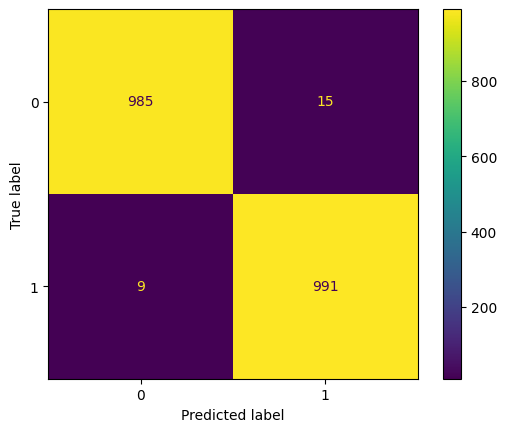

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


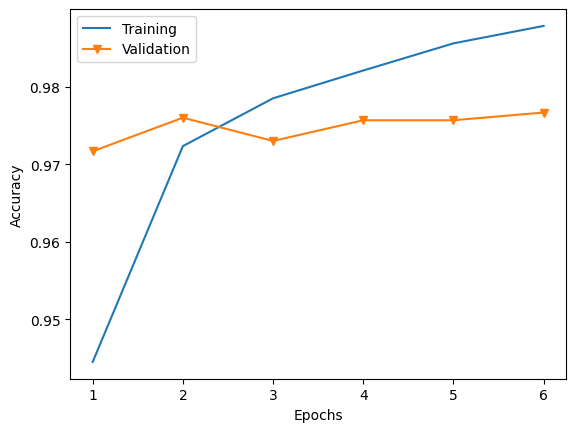

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9403    0.9760    0.9578      1000
           1     0.9939    0.9780    0.9859      1000
           2     0.9806    0.9590    0.9697      1000

    accuracy                         0.9710      3000
   macro avg     0.9716    0.9710    0.9711      3000
weighted avg     0.9716    0.9710    0.9711      3000



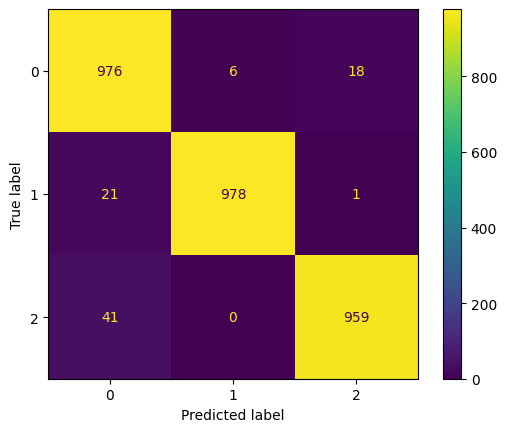

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


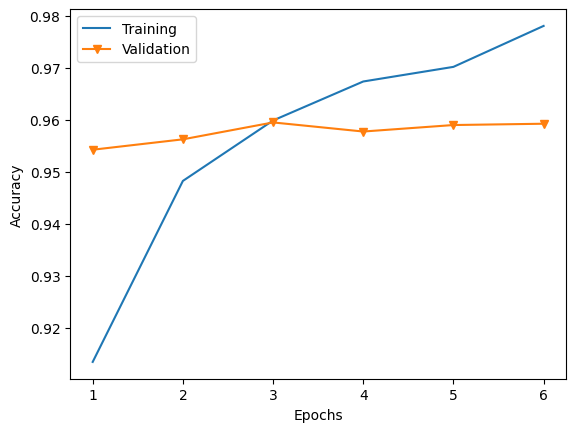

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9435    0.9510    0.9472      1000
           1     0.9761    0.9790    0.9775      1000
           2     0.9306    0.8990    0.9145      1000
           3     0.9120    0.9330    0.9224      1000

    accuracy                         0.9405      4000
   macro avg     0.9405    0.9405    0.9404      4000
weighted avg     0.9405    0.9405    0.9404      4000



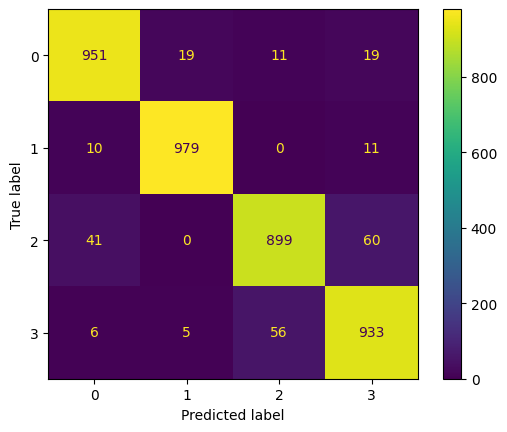

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


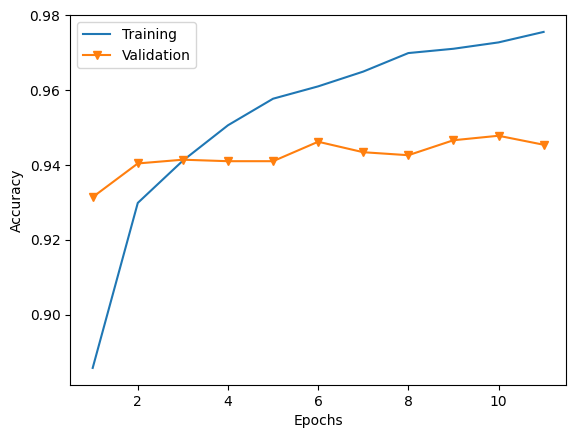

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9541    0.9560    0.9550      1000
           1     0.9868    0.9750    0.9809      1000
           2     0.9240    0.8870    0.9051      1000
           3     0.8862    0.9190    0.9023      1000
           4     0.9121    0.9240    0.9180      1000

    accuracy                         0.9322      5000
   macro avg     0.9326    0.9322    0.9323      5000
weighted avg     0.9326    0.9322    0.9323      5000



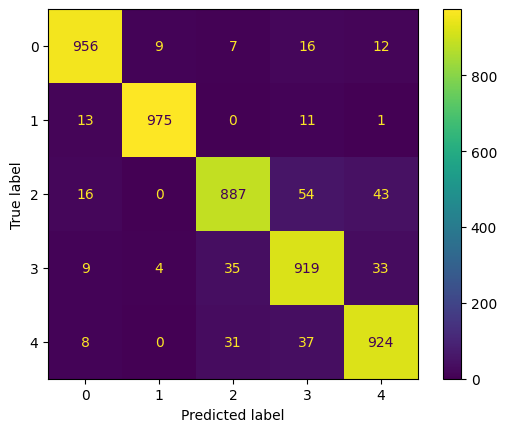

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


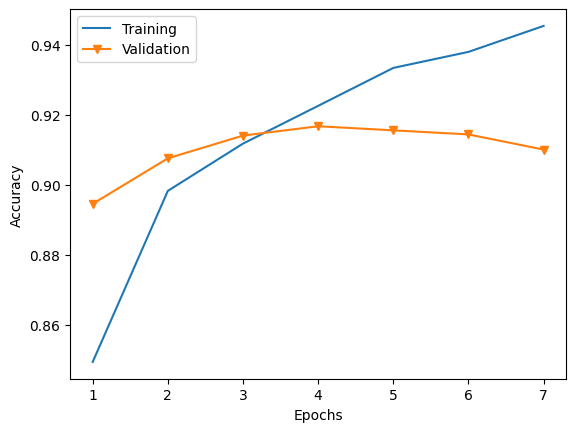

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9386    0.9630    0.9506      1000
           1     0.9899    0.9760    0.9829      1000
           2     0.9459    0.8210    0.8790      1000
           3     0.7968    0.8470    0.8211      1000
           4     0.8860    0.9330    0.9089      1000
           5     0.8596    0.8630    0.8613      1000

    accuracy                         0.9005      6000
   macro avg     0.9028    0.9005    0.9006      6000
weighted avg     0.9028    0.9005    0.9006      6000



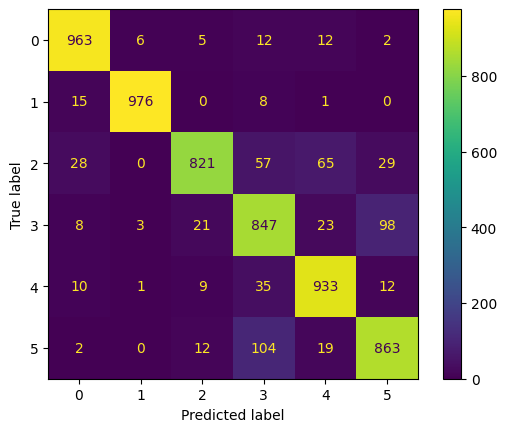

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


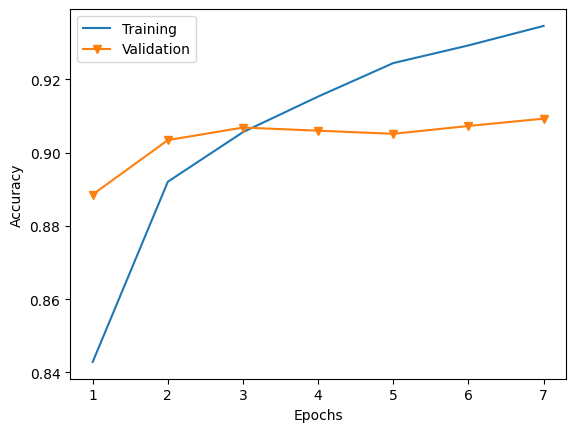

219/219 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9556    0.9460    0.9508      1000
           1     0.9869    0.9820    0.9845      1000
           2     0.9074    0.8530    0.8794      1000
           3     0.7507    0.8520    0.7981      1000
           4     0.8775    0.9240    0.9001      1000
           5     0.9171    0.7970    0.8529      1000
           6     0.8969    0.9130    0.9049      1000

    accuracy                         0.8953      7000
   macro avg     0.8989    0.8953    0.8958      7000
weighted avg     0.8989    0.8953    0.8958      7000



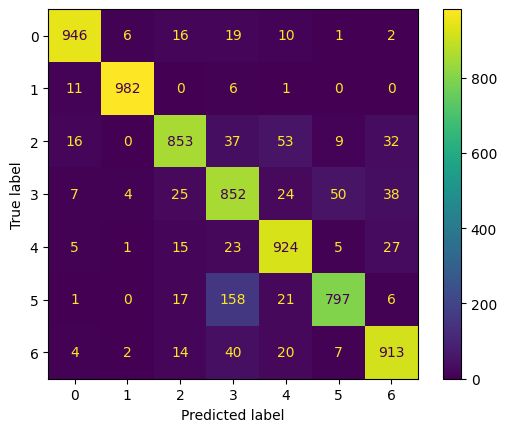

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


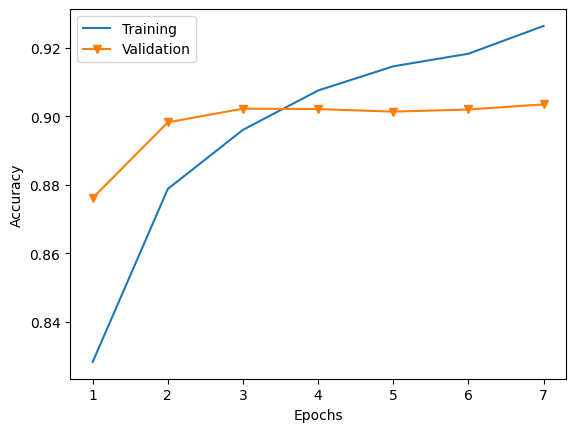

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9263    0.9550    0.9404      1000
           1     0.9879    0.9790    0.9834      1000
           2     0.9177    0.8360    0.8749      1000
           3     0.7417    0.8530    0.7935      1000
           4     0.8456    0.8870    0.8658      1000
           5     0.9033    0.7940    0.8451      1000
           6     0.9116    0.9080    0.9098      1000
           7     0.9053    0.8990    0.9022      1000

    accuracy                         0.8889      8000
   macro avg     0.8924    0.8889    0.8894      8000
weighted avg     0.8924    0.8889    0.8894      8000



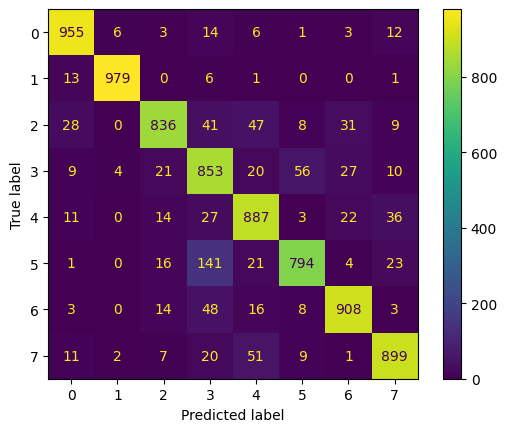

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


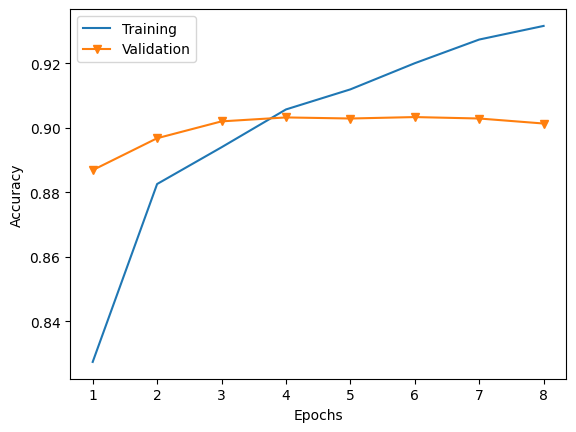

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9259    0.9000    0.9128      1000
           1     0.9750    0.9760    0.9755      1000
           2     0.9205    0.8340    0.8751      1000
           3     0.7811    0.8030    0.7919      1000
           4     0.8346    0.9030    0.8674      1000
           5     0.8712    0.8390    0.8548      1000
           6     0.8924    0.9120    0.9021      1000
           7     0.9127    0.8990    0.9058      1000
           8     0.9251    0.9630    0.9437      1000

    accuracy                         0.8921      9000
   macro avg     0.8932    0.8921    0.8921      9000
weighted avg     0.8932    0.8921    0.8921      9000



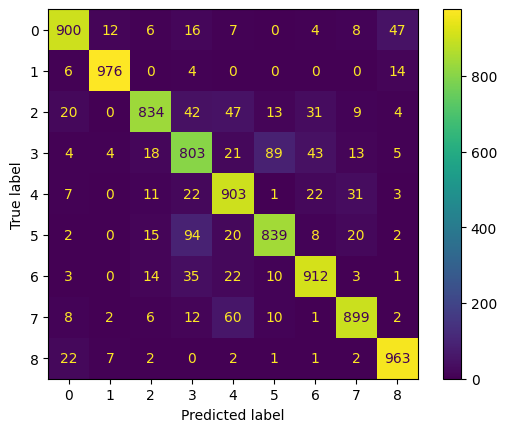

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


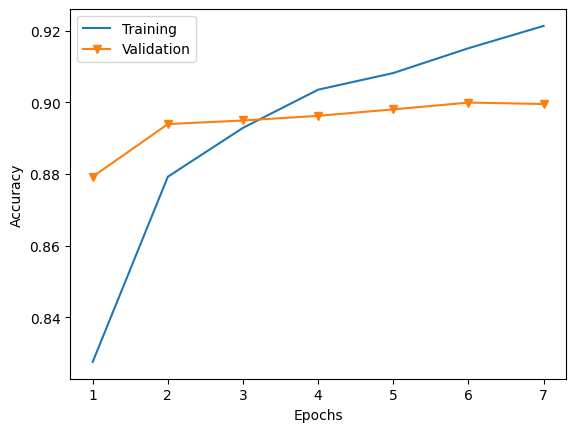

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8880    0.9120    0.8999      1000
           1     0.9166    0.9450    0.9306      1000
           2     0.9044    0.8420    0.8721      1000
           3     0.7486    0.8130    0.7795      1000
           4     0.8825    0.8490    0.8654      1000
           5     0.8734    0.8280    0.8501      1000
           6     0.8907    0.9210    0.9056      1000
           7     0.8952    0.9230    0.9089      1000
           8     0.9400    0.9250    0.9325      1000
           9     0.9275    0.8960    0.9115      1000

    accuracy                         0.8854     10000
   macro avg     0.8867    0.8854    0.8856     10000
weighted avg     0.8867    0.8854    0.8856     10000



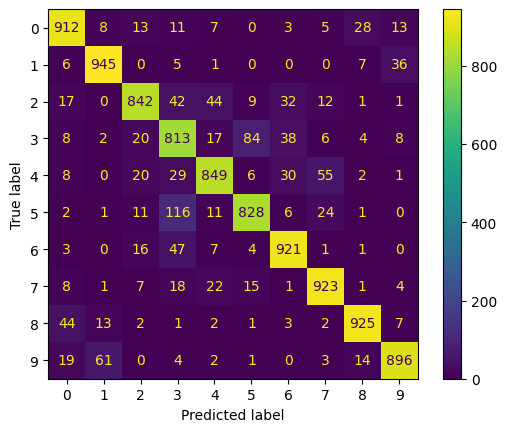

---------------------------------------------------------------------------



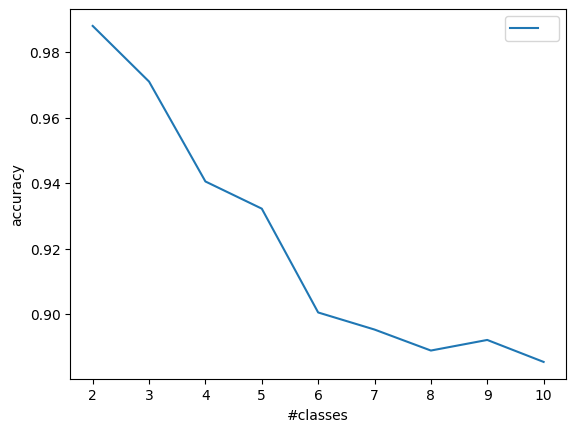

In [5]:
acc_list2 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    remove_prev_classes=False, 
    keep_same_model=False, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

## Continually adding classes to the same model

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 11.
Epoch 16: early stopping


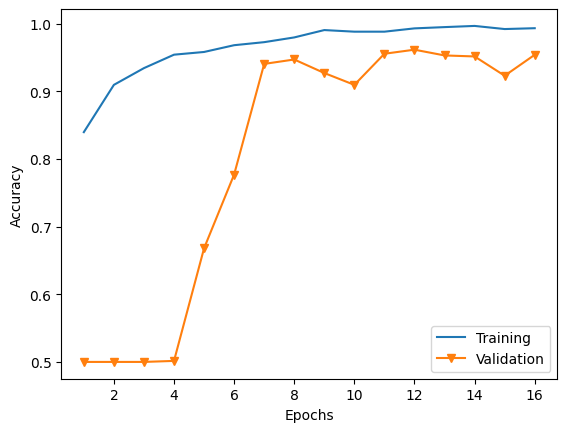

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9738    0.9280    0.9503      1000
           1     0.9312    0.9750    0.9526      1000

    accuracy                         0.9515      2000
   macro avg     0.9525    0.9515    0.9515      2000
weighted avg     0.9525    0.9515    0.9515      2000



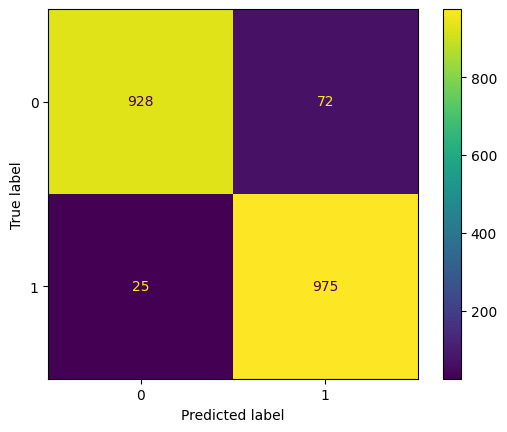

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


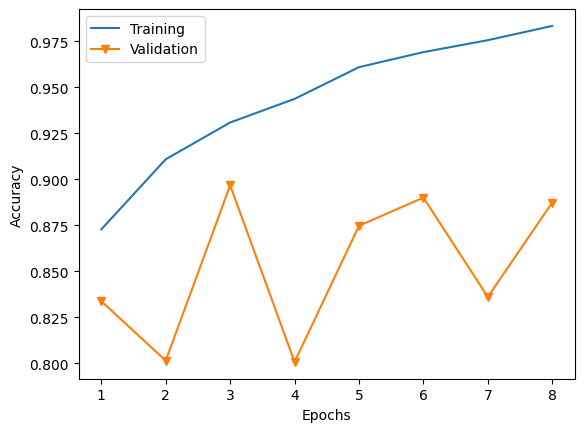

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8219    0.9090    0.8632      1000
           1     0.9466    0.9400    0.9433      1000
           2     0.9101    0.8200    0.8627      1000

    accuracy                         0.8897      3000
   macro avg     0.8929    0.8897    0.8898      3000
weighted avg     0.8929    0.8897    0.8898      3000



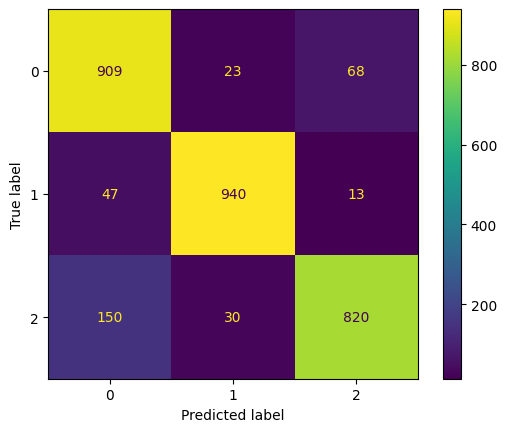

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


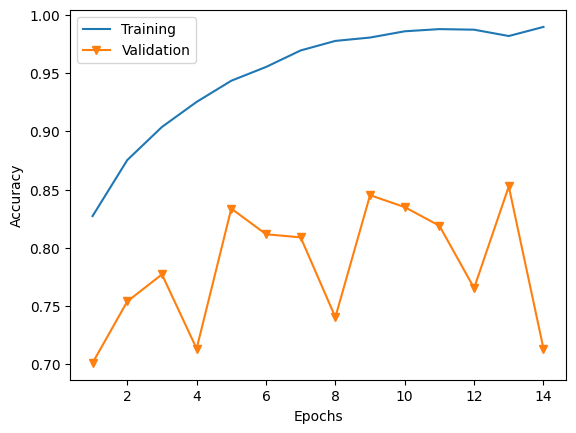

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9027    0.8440    0.8724      1000
           1     0.8780    0.9860    0.9289      1000
           2     0.8571    0.7020    0.7719      1000
           3     0.7774    0.8730    0.8224      1000

    accuracy                         0.8512      4000
   macro avg     0.8538    0.8513    0.8489      4000
weighted avg     0.8538    0.8512    0.8489      4000



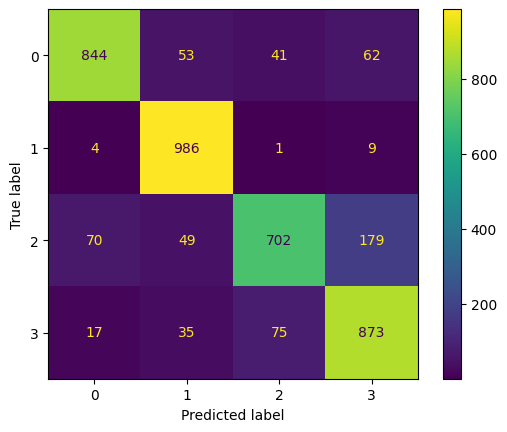

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


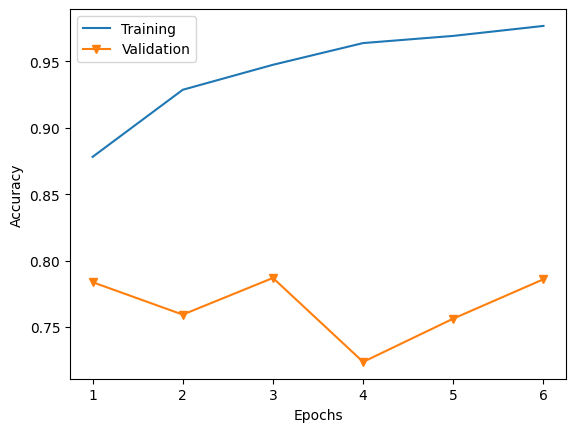

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.7187    0.9400    0.8146      1000
           1     0.9635    0.8970    0.9291      1000
           2     0.8106    0.5820    0.6775      1000
           3     0.7034    0.7920    0.7451      1000
           4     0.7361    0.6750    0.7042      1000

    accuracy                         0.7772      5000
   macro avg     0.7864    0.7772    0.7741      5000
weighted avg     0.7864    0.7772    0.7741      5000



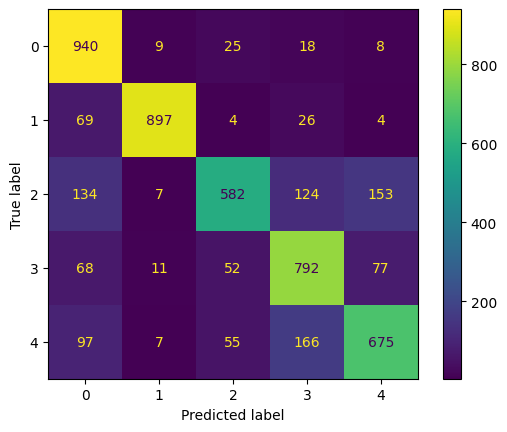

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


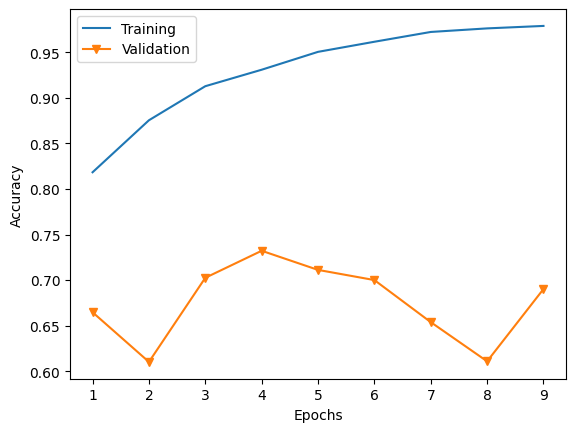

188/188 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.7957    0.8800    0.8357      1000
           1     0.9558    0.9080    0.9313      1000
           2     0.7241    0.5880    0.6490      1000
           3     0.5400    0.7220    0.6179      1000
           4     0.6889    0.7530    0.7195      1000
           5     0.7037    0.4940    0.5805      1000

    accuracy                         0.7242      6000
   macro avg     0.7347    0.7242    0.7223      6000
weighted avg     0.7347    0.7242    0.7223      6000



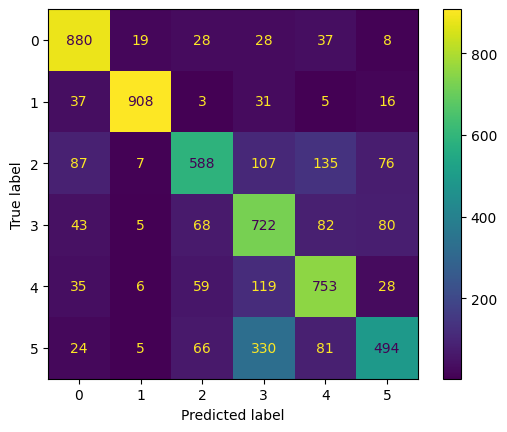

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


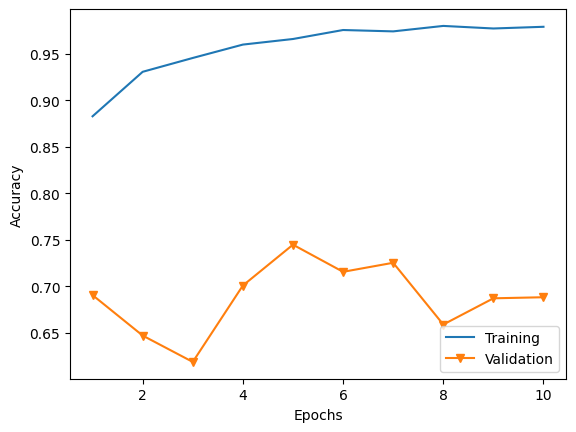

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8112    0.8810    0.8447      1000
           1     0.8520    0.9730    0.9085      1000
           2     0.7313    0.6750    0.7020      1000
           3     0.6584    0.5590    0.6047      1000
           4     0.8146    0.6020    0.6924      1000
           5     0.6638    0.6830    0.6732      1000
           6     0.6875    0.8470    0.7590      1000

    accuracy                         0.7457      7000
   macro avg     0.7455    0.7457    0.7406      7000
weighted avg     0.7455    0.7457    0.7406      7000



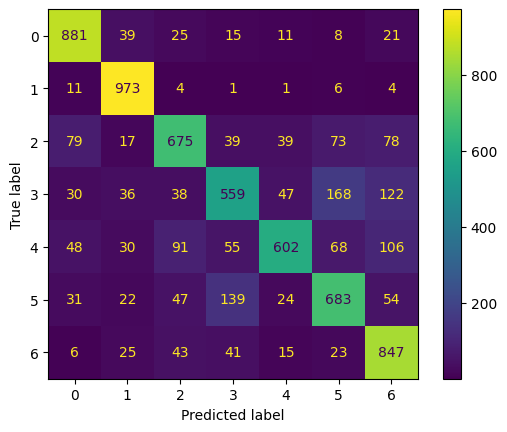

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


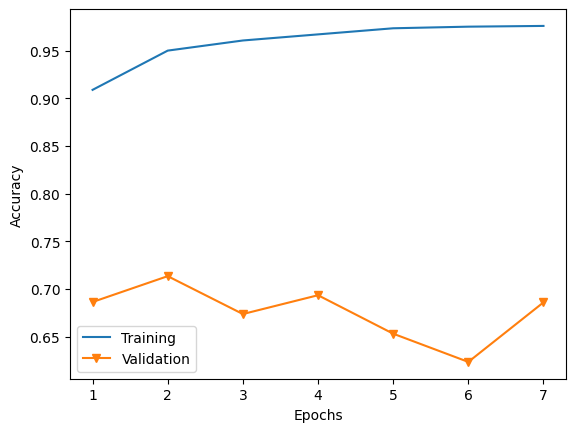

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.7641    0.8650    0.8114      1000
           1     0.9872    0.8490    0.9129      1000
           2     0.5707    0.7510    0.6485      1000
           3     0.5691    0.6010    0.5846      1000
           4     0.8591    0.5000    0.6321      1000
           5     0.6560    0.5970    0.6251      1000
           6     0.7304    0.7560    0.7430      1000
           7     0.6799    0.7540    0.7150      1000

    accuracy                         0.7091      8000
   macro avg     0.7271    0.7091    0.7091      8000
weighted avg     0.7271    0.7091    0.7091      8000



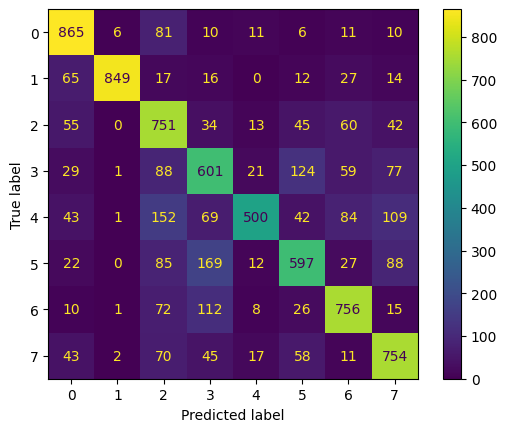

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


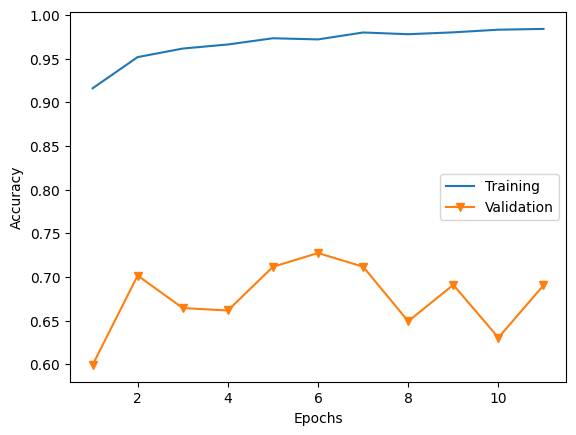

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8022    0.7870    0.7945      1000
           1     0.9462    0.8970    0.9209      1000
           2     0.8255    0.5250    0.6418      1000
           3     0.6119    0.5060    0.5539      1000
           4     0.6046    0.7890    0.6846      1000
           5     0.5453    0.7290    0.6239      1000
           6     0.6744    0.8390    0.7478      1000
           7     0.9398    0.5310    0.6786      1000
           8     0.7753    0.8970    0.8317      1000

    accuracy                         0.7222      9000
   macro avg     0.7472    0.7222    0.7198      9000
weighted avg     0.7472    0.7222    0.7198      9000



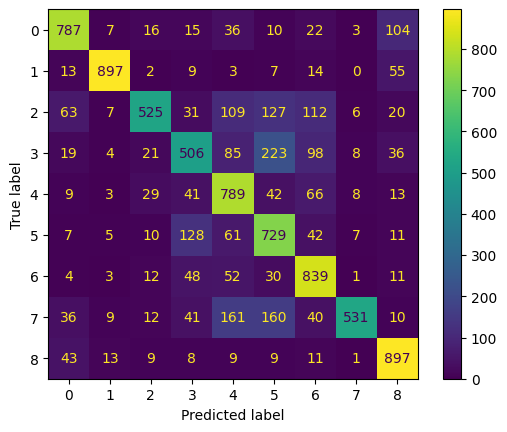

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


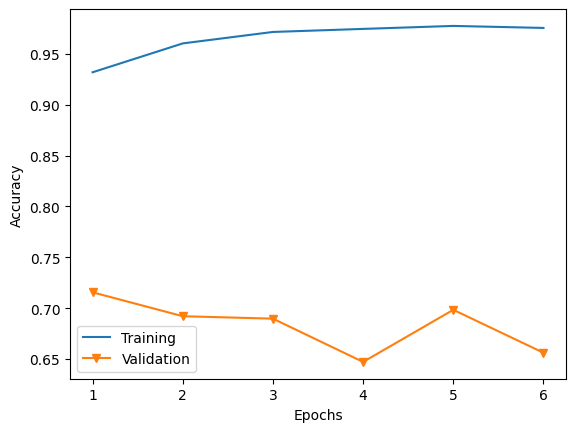

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8392    0.7360    0.7842      1000
           1     0.9077    0.8060    0.8538      1000
           2     0.7122    0.6360    0.6719      1000
           3     0.5542    0.5570    0.5556      1000
           4     0.8857    0.5190    0.6545      1000
           5     0.4771    0.8130    0.6013      1000
           6     0.8324    0.7100    0.7663      1000
           7     0.6518    0.8200    0.7263      1000
           8     0.7612    0.8830    0.8176      1000
           9     0.8454    0.6560    0.7387      1000

    accuracy                         0.7136     10000
   macro avg     0.7467    0.7136    0.7170     10000
weighted avg     0.7467    0.7136    0.7170     10000



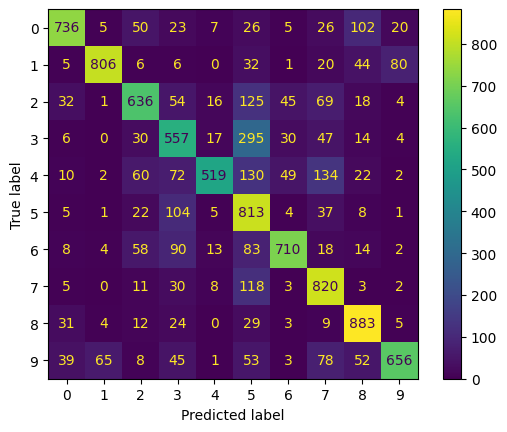

---------------------------------------------------------------------------



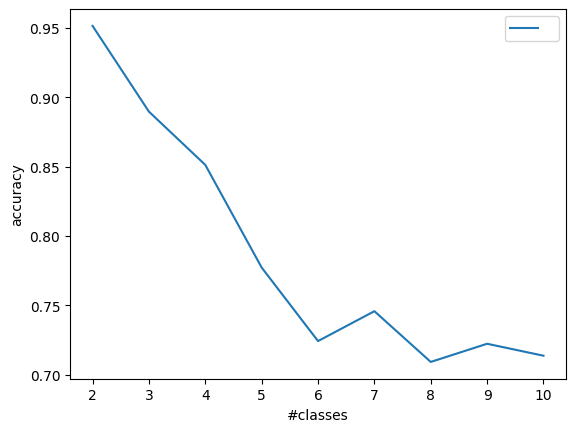

In [6]:
acc_list3 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    load_dataset_fn_kwargs={"preprocess": "min-max"}, 
    remove_prev_classes=False, 
    keep_same_model=True, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


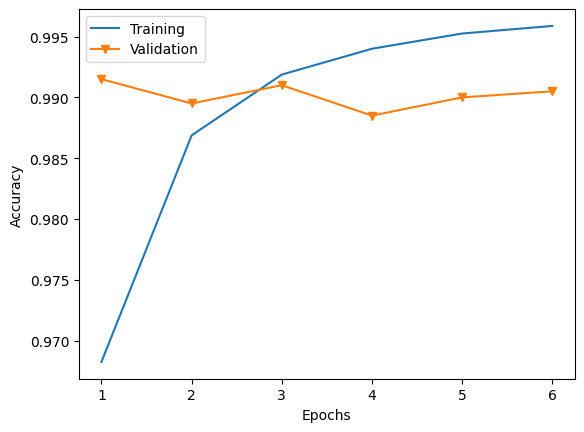

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9880    0.9860    0.9870      1000
           1     0.9860    0.9880    0.9870      1000

    accuracy                         0.9870      2000
   macro avg     0.9870    0.9870    0.9870      2000
weighted avg     0.9870    0.9870    0.9870      2000



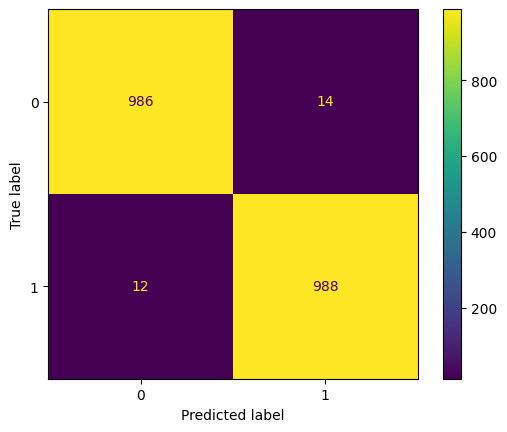

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


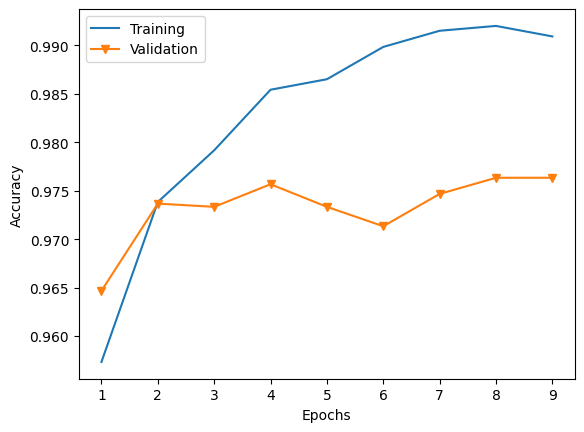

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9698    0.9650    0.9674      1000
           1     0.9880    0.9880    0.9880      1000
           2     0.9761    0.9810    0.9786      1000

    accuracy                         0.9780      3000
   macro avg     0.9780    0.9780    0.9780      3000
weighted avg     0.9780    0.9780    0.9780      3000



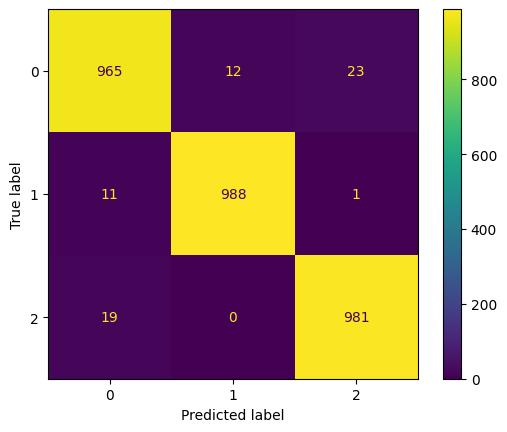

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


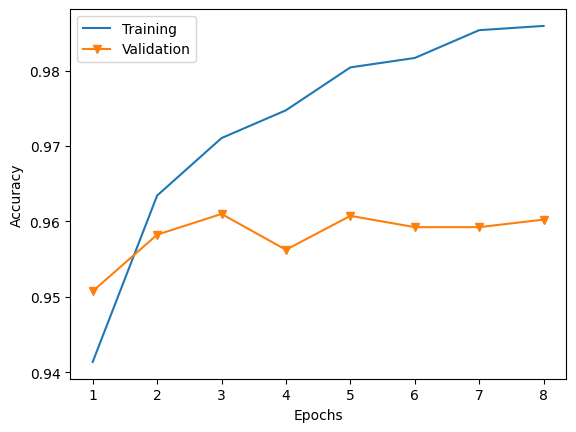

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9650    0.9650    0.9650      1000
           1     0.9831    0.9870    0.9850      1000
           2     0.9714    0.8820    0.9245      1000
           3     0.8888    0.9670    0.9262      1000

    accuracy                         0.9503      4000
   macro avg     0.9521    0.9503    0.9502      4000
weighted avg     0.9521    0.9503    0.9502      4000



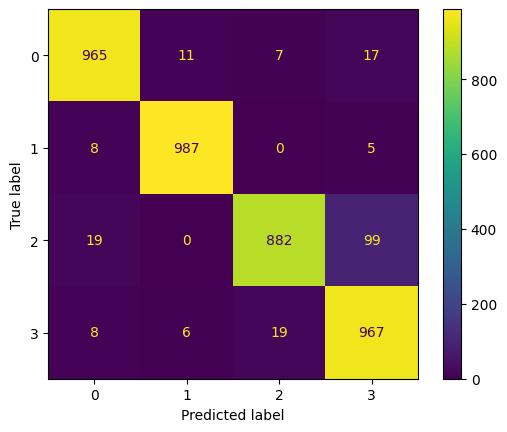

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


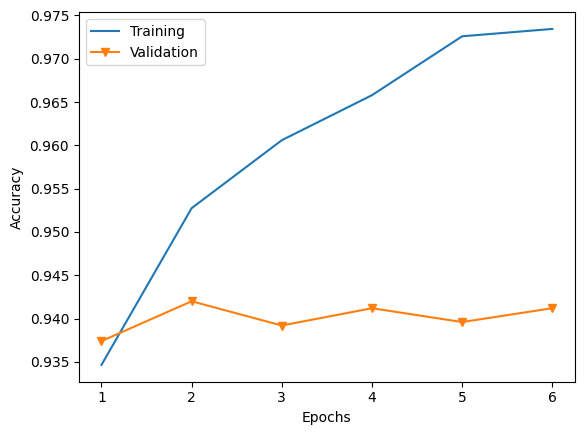

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9590    0.9590    0.9590      1000
           1     0.9830    0.9850    0.9840      1000
           2     0.9524    0.8600    0.9038      1000
           3     0.8956    0.9350    0.9149      1000
           4     0.8963    0.9420    0.9186      1000

    accuracy                         0.9362      5000
   macro avg     0.9373    0.9362    0.9361      5000
weighted avg     0.9373    0.9362    0.9361      5000



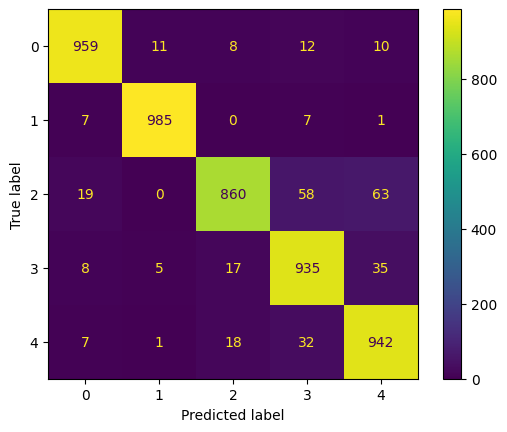

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


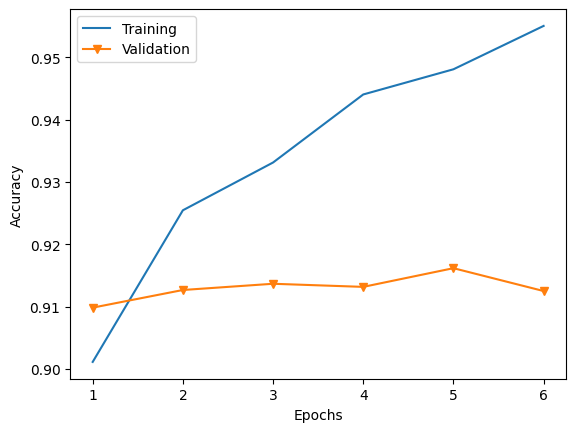

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9617    0.9530    0.9573      1000
           1     0.9909    0.9800    0.9854      1000
           2     0.9301    0.8650    0.8964      1000
           3     0.7923    0.8470    0.8188      1000
           4     0.8941    0.9200    0.9069      1000
           5     0.8589    0.8520    0.8554      1000

    accuracy                         0.9028      6000
   macro avg     0.9047    0.9028    0.9034      6000
weighted avg     0.9047    0.9028    0.9034      6000



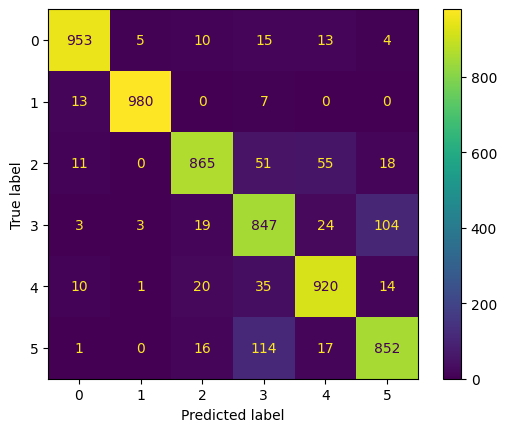

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


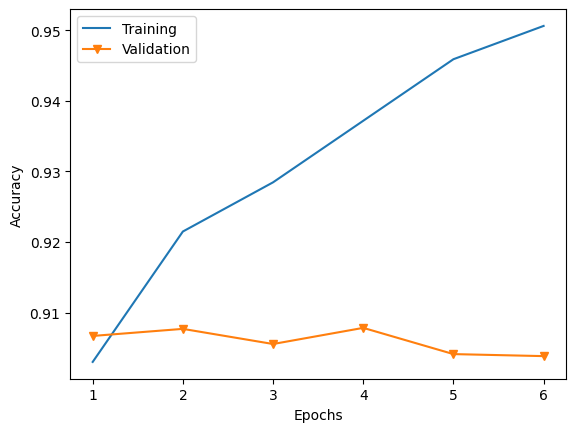

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9445    0.9530    0.9487      1000
           1     0.9889    0.9770    0.9829      1000
           2     0.9075    0.8440    0.8746      1000
           3     0.7873    0.8070    0.7970      1000
           4     0.8945    0.9070    0.9007      1000
           5     0.8638    0.8560    0.8599      1000
           6     0.8821    0.9200    0.9006      1000

    accuracy                         0.8949      7000
   macro avg     0.8955    0.8949    0.8949      7000
weighted avg     0.8955    0.8949    0.8949      7000



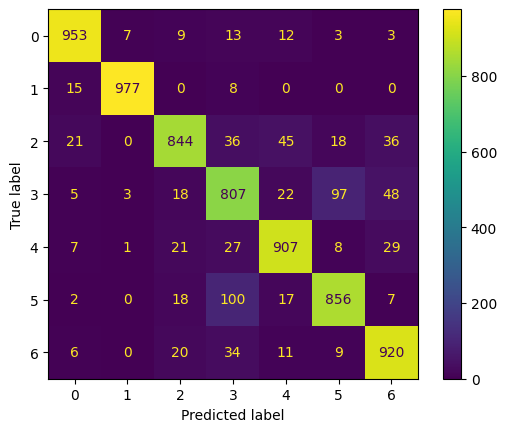

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


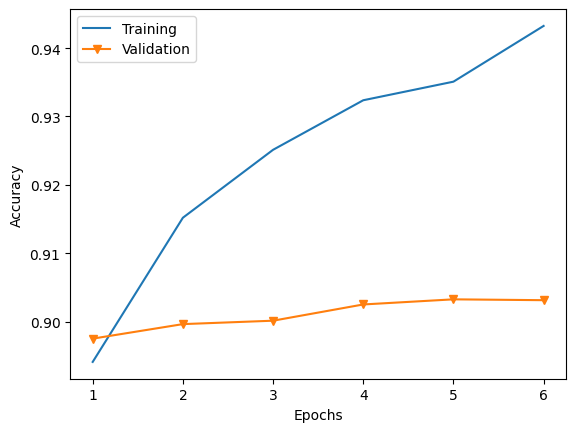

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9456    0.9390    0.9423      1000
           1     0.9899    0.9780    0.9839      1000
           2     0.9132    0.8520    0.8815      1000
           3     0.7902    0.8060    0.7980      1000
           4     0.8632    0.8900    0.8764      1000
           5     0.8563    0.8580    0.8571      1000
           6     0.9011    0.9020    0.9015      1000
           7     0.8905    0.9190    0.9045      1000

    accuracy                         0.8930      8000
   macro avg     0.8938    0.8930    0.8932      8000
weighted avg     0.8938    0.8930    0.8932      8000



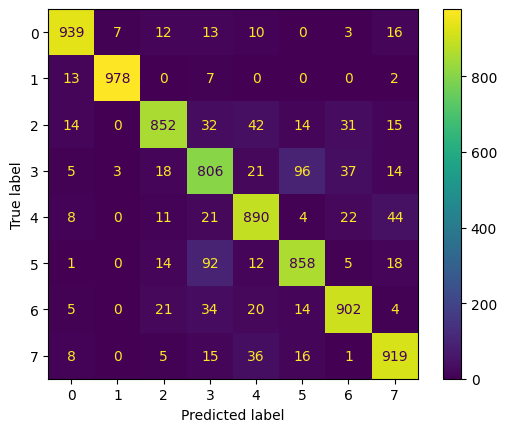

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


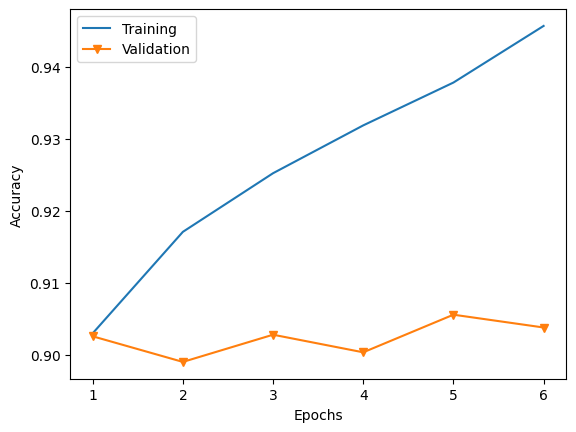

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9213    0.9020    0.9116      1000
           1     0.9848    0.9700    0.9773      1000
           2     0.9172    0.8420    0.8780      1000
           3     0.7900    0.8090    0.7994      1000
           4     0.8421    0.8960    0.8682      1000
           5     0.8609    0.8420    0.8514      1000
           6     0.9107    0.9080    0.9094      1000
           7     0.8829    0.9050    0.8938      1000
           8     0.9252    0.9530    0.9389      1000

    accuracy                         0.8919      9000
   macro avg     0.8928    0.8919    0.8920      9000
weighted avg     0.8928    0.8919    0.8920      9000



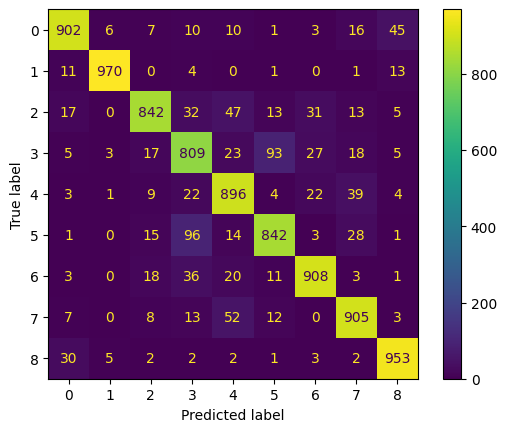

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


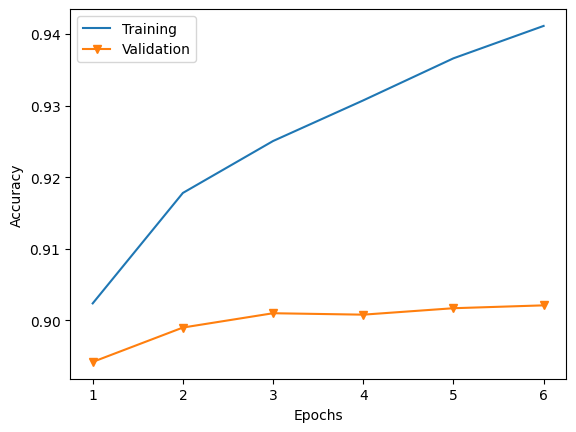

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9132    0.8940    0.9035      1000
           1     0.9621    0.8890    0.9241      1000
           2     0.9295    0.8310    0.8775      1000
           3     0.8091    0.7970    0.8030      1000
           4     0.8760    0.8690    0.8725      1000
           5     0.8425    0.8720    0.8570      1000
           6     0.8989    0.9160    0.9074      1000
           7     0.8887    0.9340    0.9108      1000
           8     0.9147    0.9440    0.9291      1000
           9     0.8650    0.9420    0.9019      1000

    accuracy                         0.8888     10000
   macro avg     0.8900    0.8888    0.8887     10000
weighted avg     0.8900    0.8888    0.8887     10000



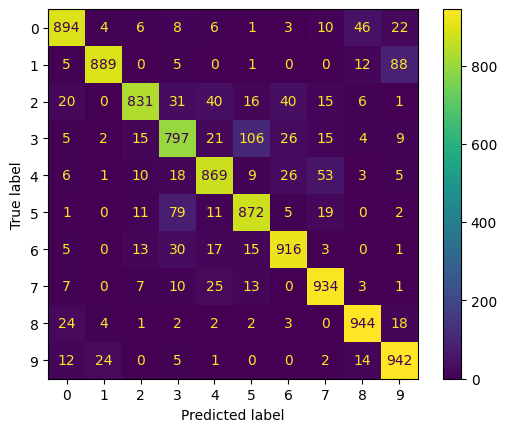

---------------------------------------------------------------------------



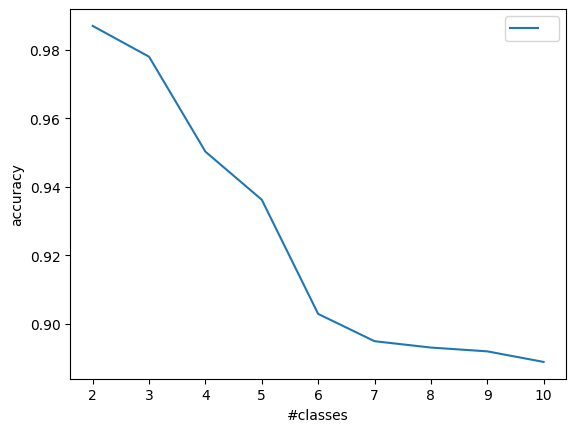

In [7]:
acc_list4 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    remove_prev_classes=False, 
    keep_same_model=True, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

## Continually adding classes to the same model without the previous data

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 11.
Epoch 16: early stopping


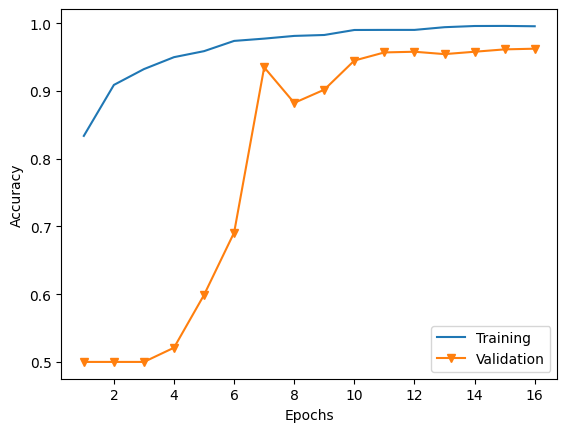

63/63 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9686    0.9550    0.9617      1000
           1     0.9556    0.9690    0.9623      1000

    accuracy                         0.9620      2000
   macro avg     0.9621    0.9620    0.9620      2000
weighted avg     0.9621    0.9620    0.9620      2000



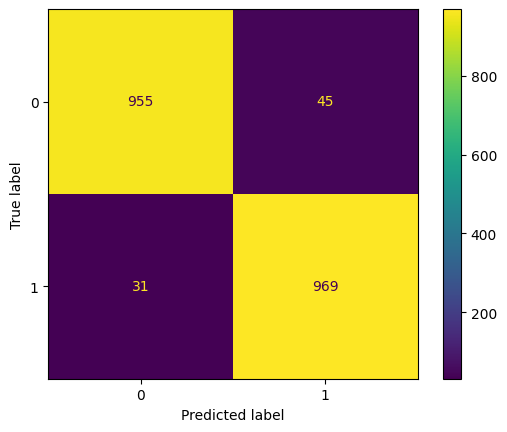

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


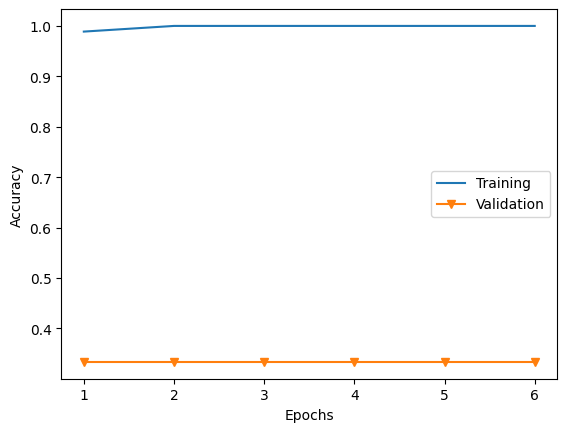

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.3333    1.0000    0.5000      1000

    accuracy                         0.3333      3000
   macro avg     0.1111    0.3333    0.1667      3000
weighted avg     0.1111    0.3333    0.1667      3000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


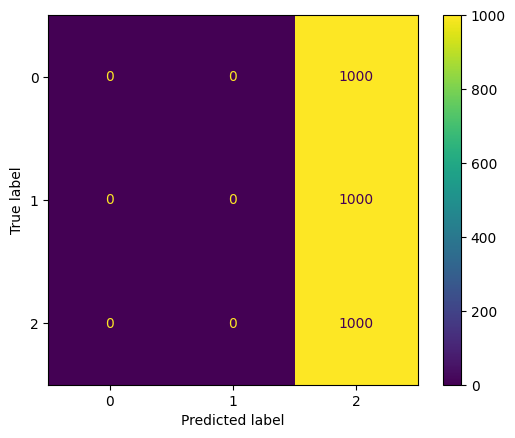

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


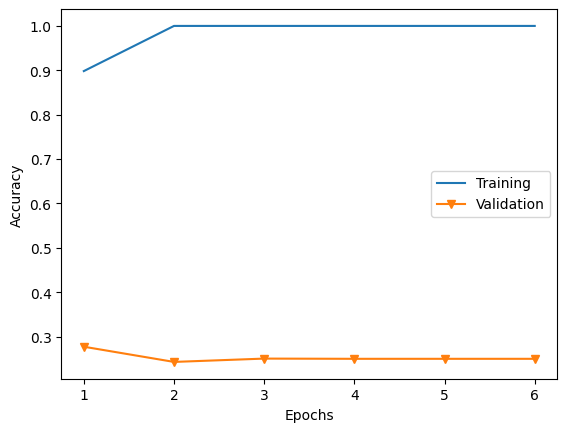

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.2557    0.8480    0.3930      1000
           3     0.3904    0.2670    0.3171      1000

    accuracy                         0.2787      4000
   macro avg     0.1615    0.2787    0.1775      4000
weighted avg     0.1615    0.2787    0.1775      4000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


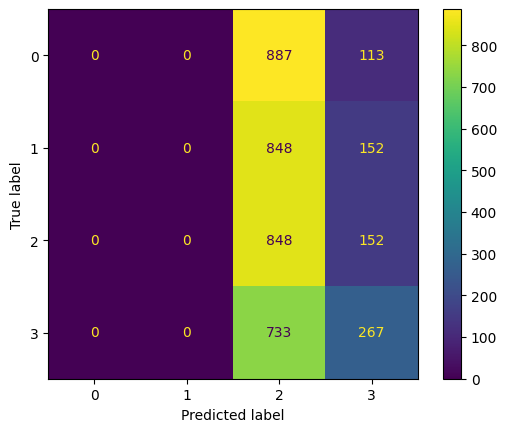

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


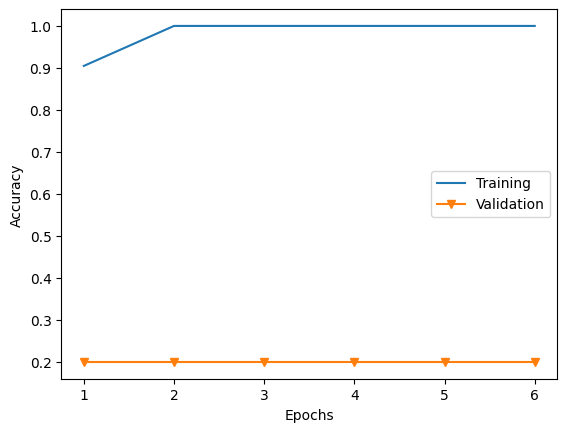

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.2000    1.0000    0.3333      1000

    accuracy                         0.2000      5000
   macro avg     0.0400    0.2000    0.0667      5000
weighted avg     0.0400    0.2000    0.0667      5000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


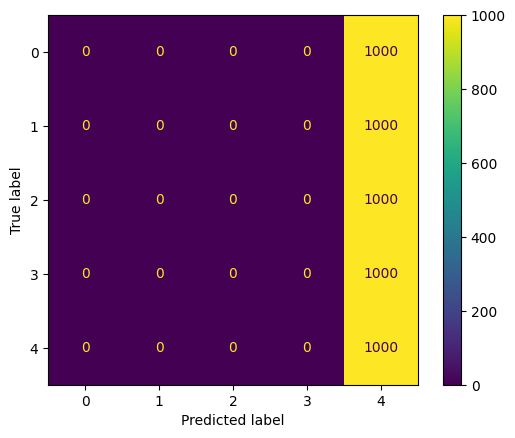

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


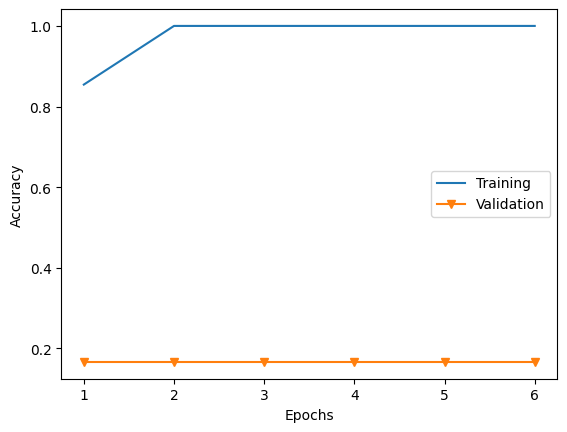

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.1667    1.0000    0.2857      1000

    accuracy                         0.1667      6000
   macro avg     0.0278    0.1667    0.0476      6000
weighted avg     0.0278    0.1667    0.0476      6000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


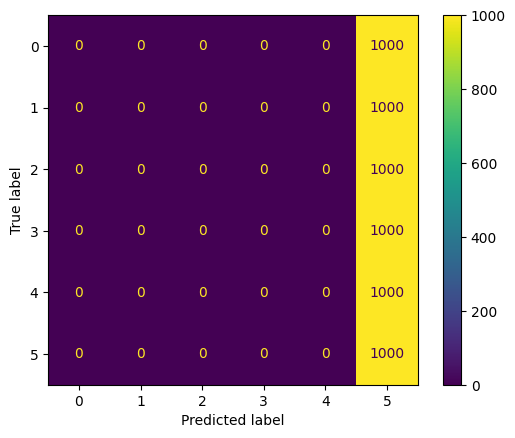

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


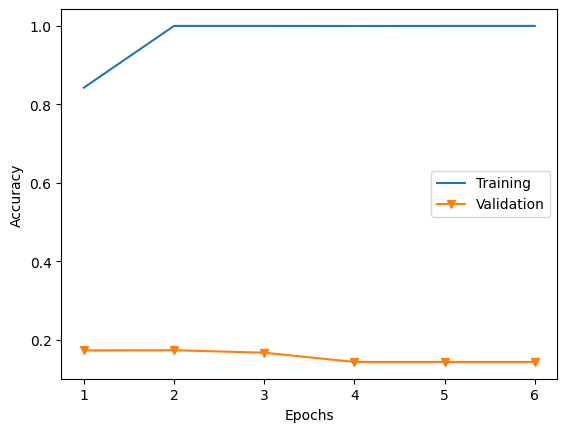

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.1939    0.4950    0.2786      1000
           6     0.1484    0.6600    0.2423      1000

    accuracy                         0.1650      7000
   macro avg     0.0489    0.1650    0.0744      7000
weighted avg     0.0489    0.1650    0.0744      7000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


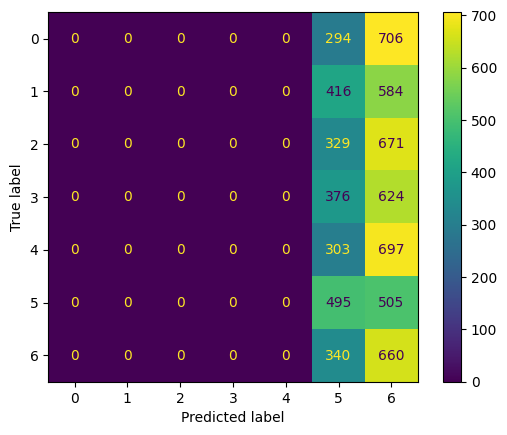

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


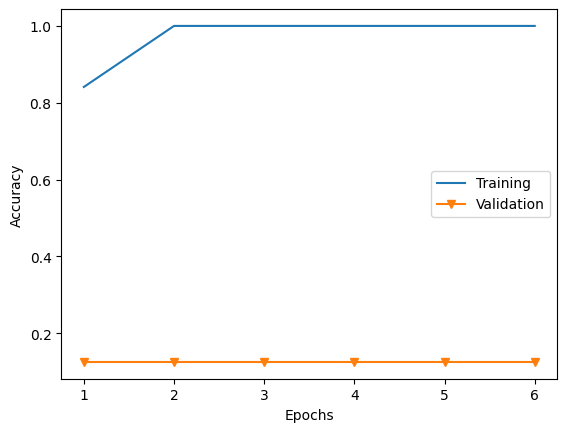

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.1253    0.9990    0.2227      1000

    accuracy                         0.1249      8000
   macro avg     0.0157    0.1249    0.0278      8000
weighted avg     0.0157    0.1249    0.0278      8000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


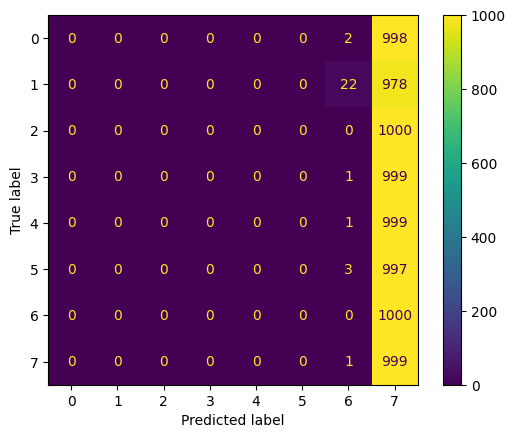

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


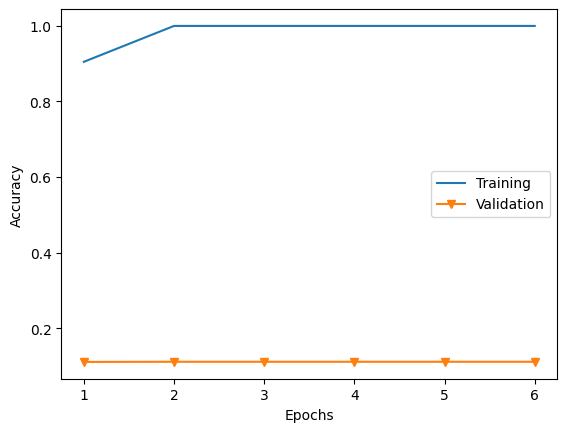

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.1728    0.0140    0.0259      1000
           8     0.1111    0.9910    0.1998      1000

    accuracy                         0.1117      9000
   macro avg     0.0316    0.1117    0.0251      9000
weighted avg     0.0316    0.1117    0.0251      9000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


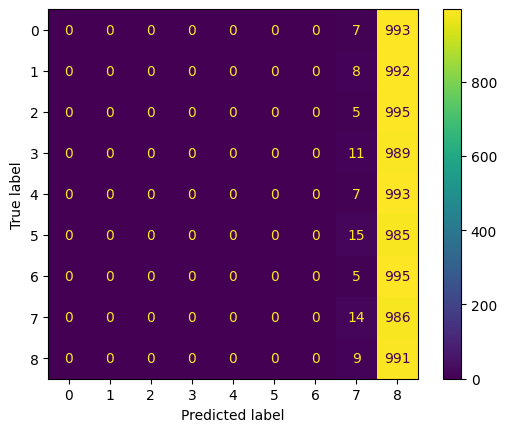

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


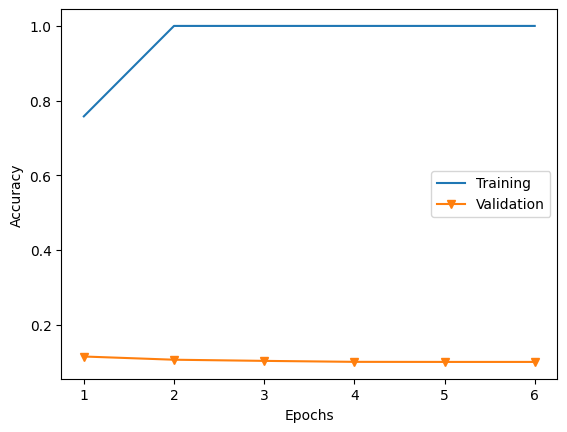

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.0000    0.0000    0.0000      1000
           8     0.0811    0.2070    0.1166      1000
           9     0.1228    0.9150    0.2166      1000

    accuracy                         0.1122     10000
   macro avg     0.0204    0.1122    0.0333     10000
weighted avg     0.0204    0.1122    0.0333     10000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


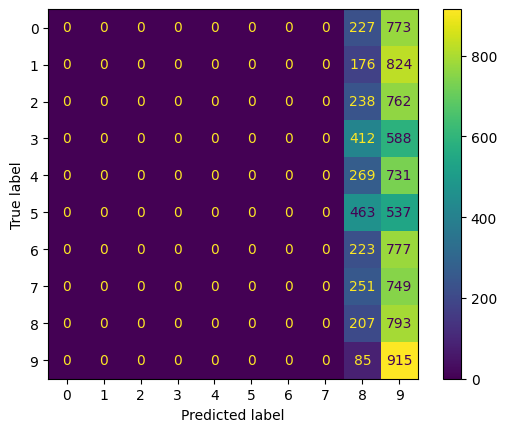

---------------------------------------------------------------------------



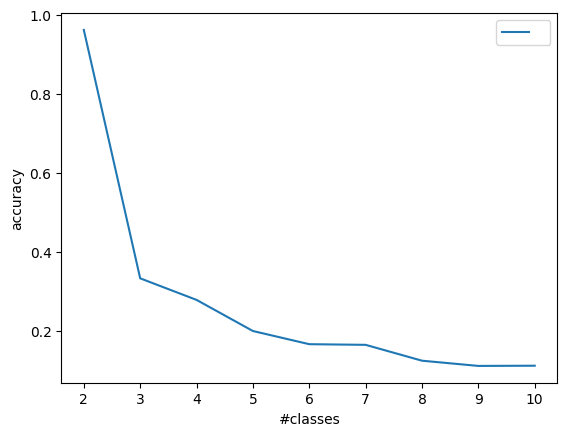

In [8]:
acc_list5 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    load_dataset_fn_kwargs={"preprocess": "min-max"}, 
    remove_prev_classes=True, 
    keep_same_model=True, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


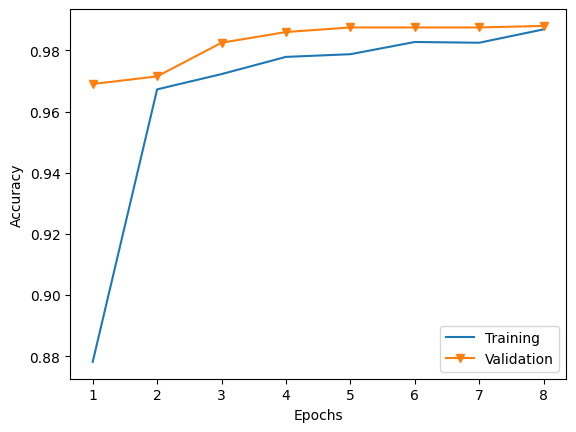

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9898    0.9700    0.9798      1000
           1     0.9706    0.9900    0.9802      1000

    accuracy                         0.9800      2000
   macro avg     0.9802    0.9800    0.9800      2000
weighted avg     0.9802    0.9800    0.9800      2000



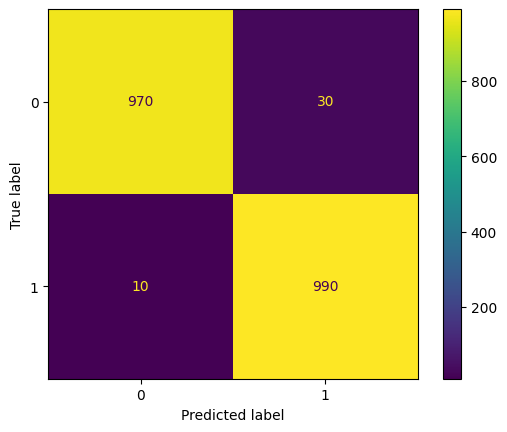

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


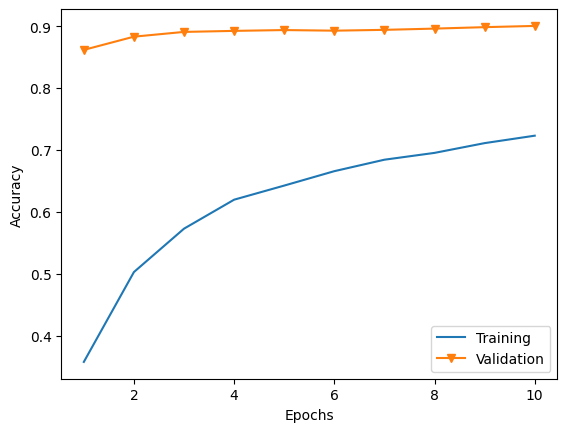

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8344    0.9270    0.8783      1000
           1     0.9042    0.9820    0.9415      1000
           2     0.9639    0.7740    0.8586      1000

    accuracy                         0.8943      3000
   macro avg     0.9008    0.8943    0.8928      3000
weighted avg     0.9008    0.8943    0.8928      3000



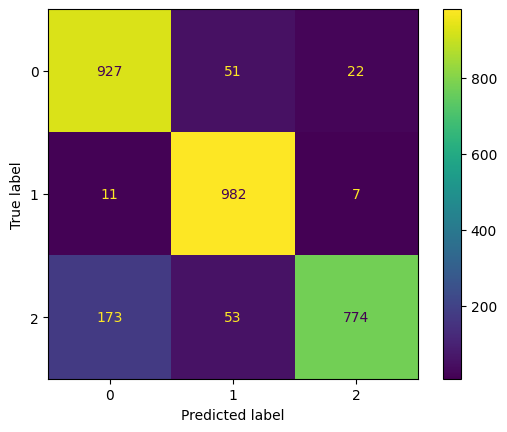

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


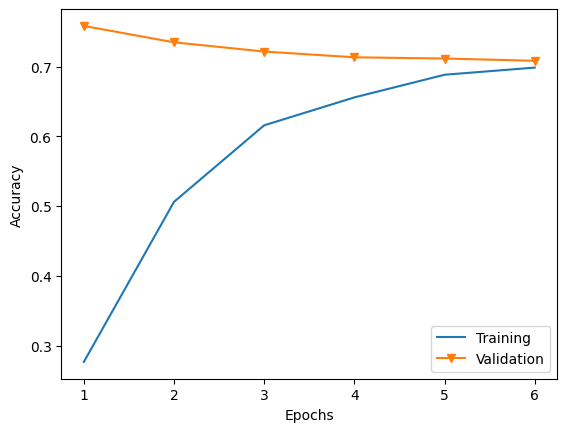

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.7687    0.9270    0.8404      1000
           1     0.8053    0.9640    0.8776      1000
           2     0.7539    0.5850    0.6588      1000
           3     0.6821    0.5600    0.6150      1000

    accuracy                         0.7590      4000
   macro avg     0.7525    0.7590    0.7480      4000
weighted avg     0.7525    0.7590    0.7480      4000



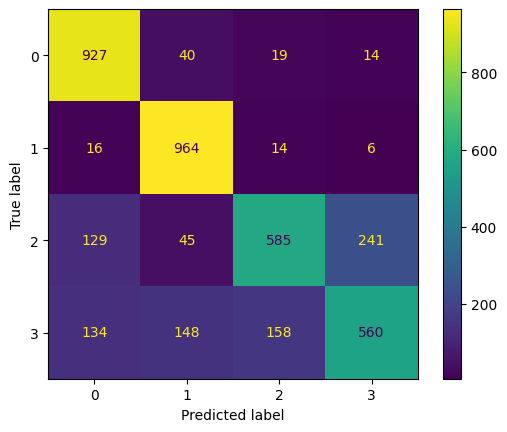

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


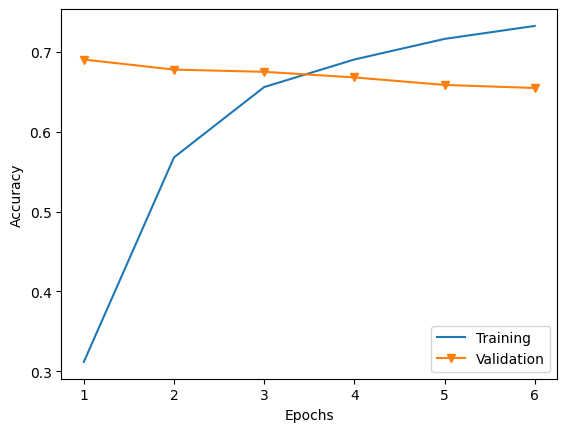

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8368    0.8000    0.8180      1000
           1     0.7010    0.9800    0.8173      1000
           2     0.5860    0.3270    0.4198      1000
           3     0.7972    0.5070    0.6198      1000
           4     0.5640    0.8190    0.6680      1000

    accuracy                         0.6866      5000
   macro avg     0.6970    0.6866    0.6686      5000
weighted avg     0.6970    0.6866    0.6686      5000



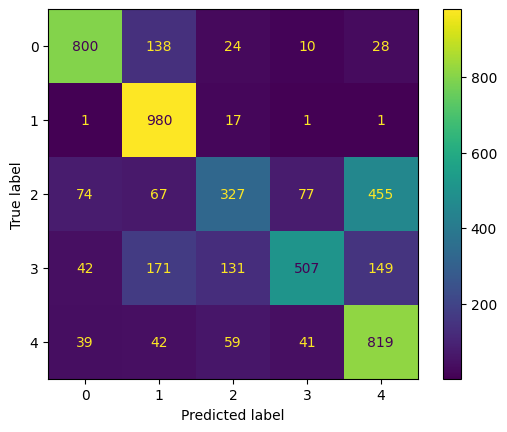

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


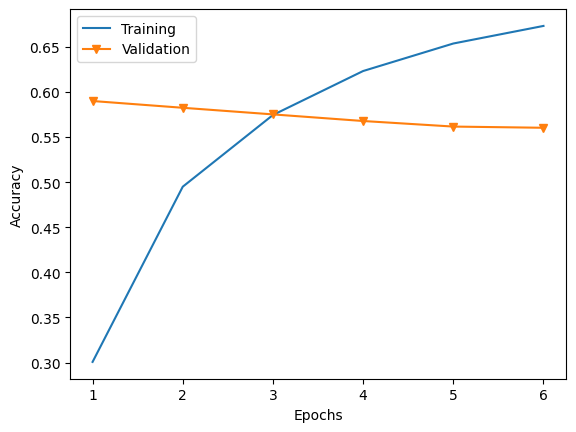

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.8339    0.7630    0.7969      1000
           1     0.7215    0.9480    0.8194      1000
           2     0.4667    0.2660    0.3389      1000
           3     0.5200    0.1430    0.2243      1000
           4     0.5423    0.8340    0.6572      1000
           5     0.4575    0.6350    0.5318      1000

    accuracy                         0.5982      6000
   macro avg     0.5903    0.5982    0.5614      6000
weighted avg     0.5903    0.5982    0.5614      6000



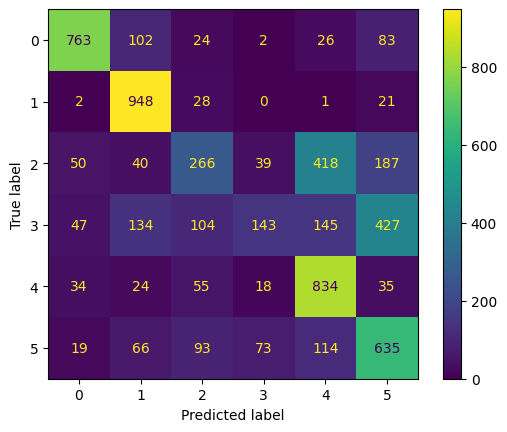

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


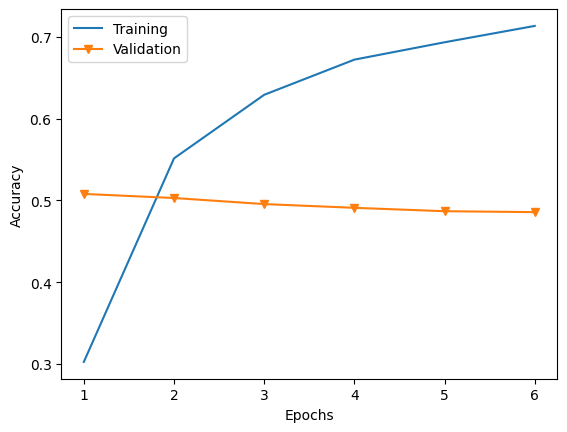

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8668    0.5920    0.7035      1000
           1     0.6572    0.9260    0.7688      1000
           2     0.3544    0.2300    0.2790      1000
           3     0.3747    0.1360    0.1996      1000
           4     0.4906    0.3900    0.4345      1000
           5     0.5313    0.5770    0.5532      1000
           6     0.3449    0.6950    0.4610      1000

    accuracy                         0.5066      7000
   macro avg     0.5171    0.5066    0.4857      7000
weighted avg     0.5171    0.5066    0.4857      7000



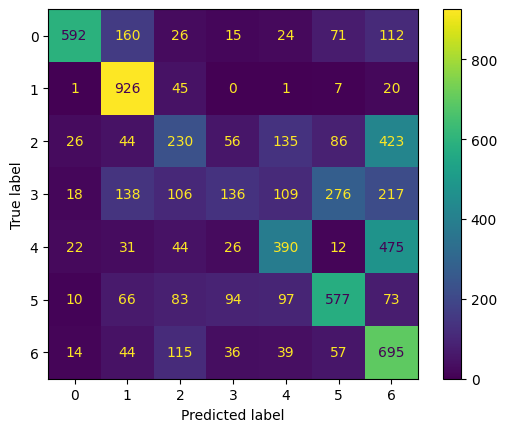

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


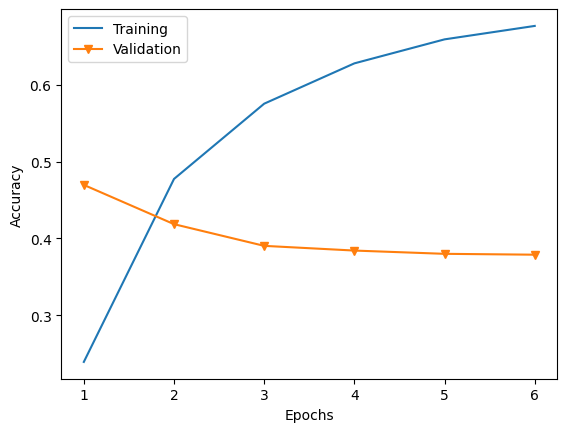

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8510    0.4340    0.5748      1000
           1     0.7467    0.8960    0.8145      1000
           2     0.2867    0.1620    0.2070      1000
           3     0.3577    0.0930    0.1476      1000
           4     0.4258    0.2180    0.2884      1000
           5     0.4929    0.5910    0.5375      1000
           6     0.3071    0.7180    0.4302      1000
           7     0.4739    0.6710    0.5555      1000

    accuracy                         0.4729      8000
   macro avg     0.4927    0.4729    0.4444      8000
weighted avg     0.4927    0.4729    0.4444      8000



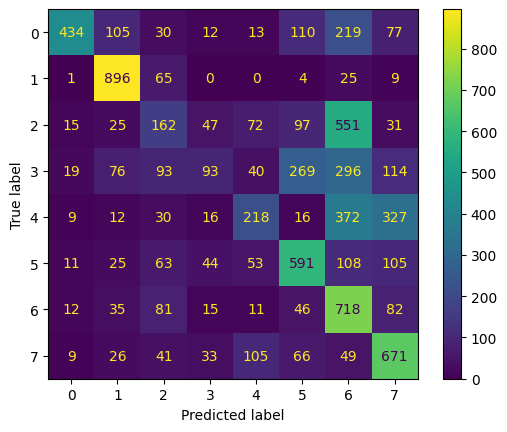

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


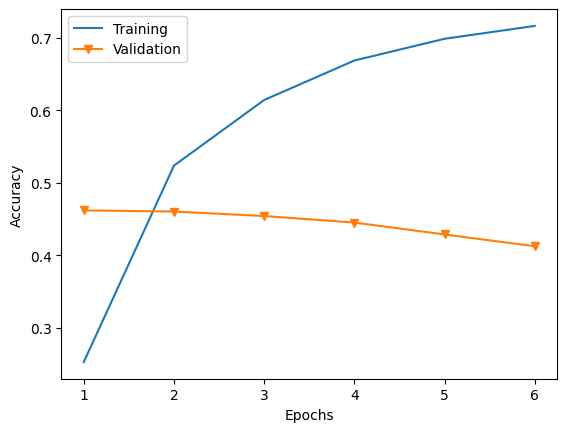

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.3435    0.0900    0.1426      1000
           1     0.8288    0.7650    0.7956      1000
           2     0.3738    0.1600    0.2241      1000
           3     0.3152    0.1100    0.1631      1000
           4     0.4682    0.2650    0.3384      1000
           5     0.5096    0.5560    0.5318      1000
           6     0.3560    0.7220    0.4769      1000
           7     0.4814    0.6590    0.5564      1000
           8     0.4405    0.8740    0.5858      1000

    accuracy                         0.4668      9000
   macro avg     0.4575    0.4668    0.4239      9000
weighted avg     0.4575    0.4668    0.4239      9000



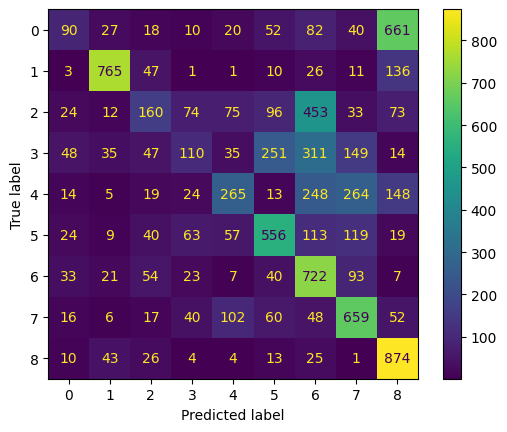

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


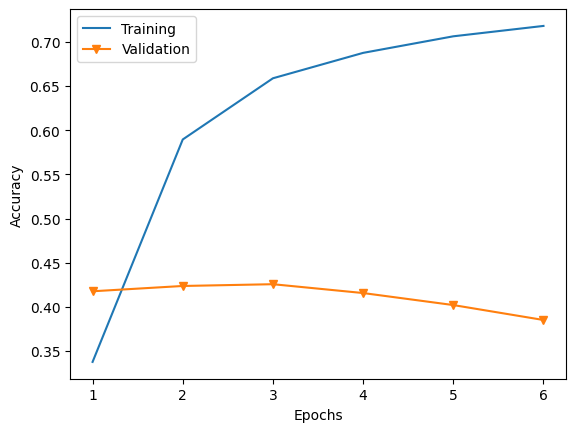

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.3184    0.1490    0.2030      1000
           1     0.6014    0.0830    0.1459      1000
           2     0.3772    0.1490    0.2136      1000
           3     0.2944    0.1590    0.2065      1000
           4     0.5660    0.2100    0.3063      1000
           5     0.5365    0.5150    0.5255      1000
           6     0.3344    0.6340    0.4378      1000
           7     0.5055    0.6390    0.5645      1000
           8     0.5012    0.8450    0.6292      1000
           9     0.3769    0.8600    0.5241      1000

    accuracy                         0.4243     10000
   macro avg     0.4412    0.4243    0.3756     10000
weighted avg     0.4412    0.4243    0.3756     10000



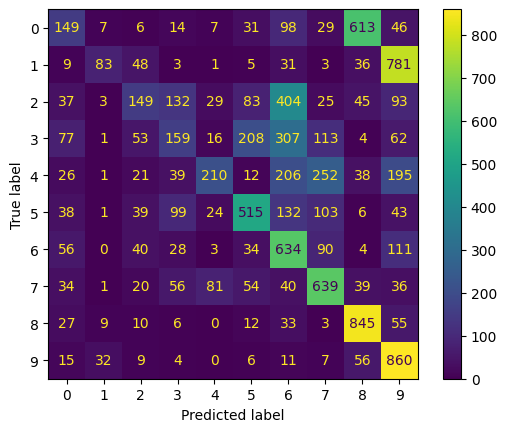

---------------------------------------------------------------------------



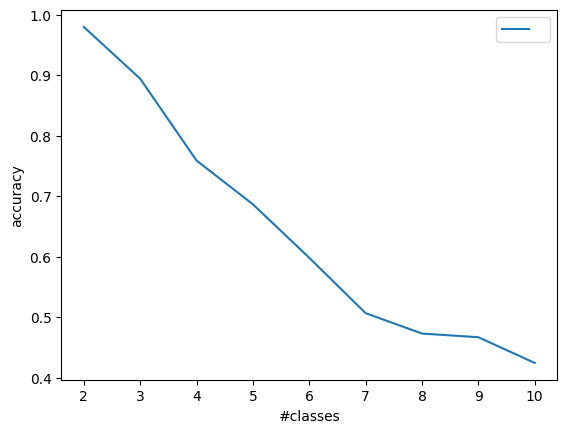

In [3]:
from tensorflow.keras import optimizers

from masked_loss import MaskedLoss
from model import get_compile_args


acc_list6 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    load_dataset_fn_kwargs={"onehot_labels": True}, 
    remove_prev_classes=True, 
    keep_same_model=True, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    compile_args=get_compile_args(
        optimizer=optimizers.Adam(learning_rate=5e-5), 
        loss=MaskedLoss()
    ),
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS
)

## Continually adding classes to the same model without the previous data but with a replay buffer

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


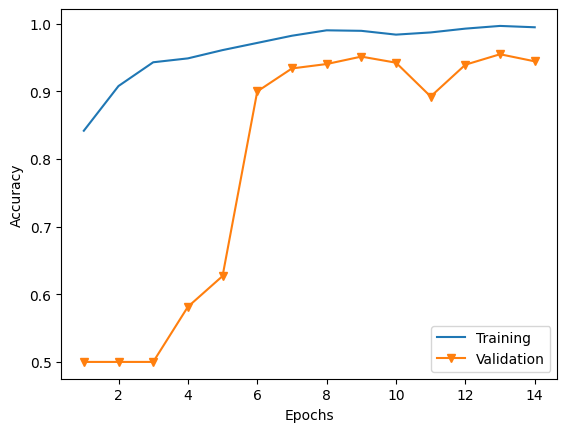

63/63 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

           0     0.9508    0.9670    0.9588      1000
           1     0.9664    0.9500    0.9581      1000

    accuracy                         0.9585      2000
   macro avg     0.9586    0.9585    0.9585      2000
weighted avg     0.9586    0.9585    0.9585      2000



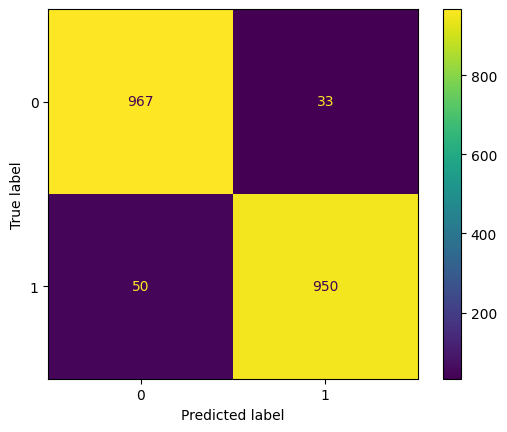

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


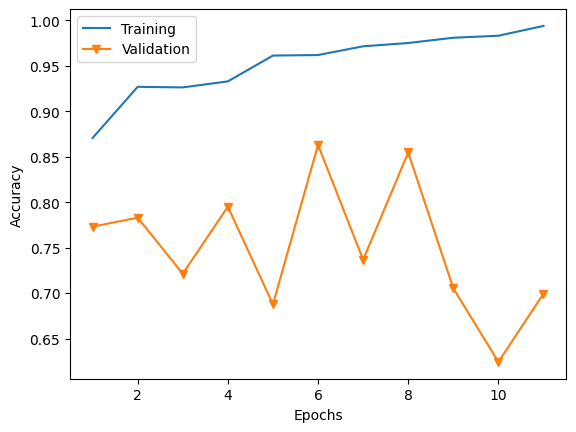

94/94 [==============================] - 0s 4ms/step
              precision    recall  f1-score   support

           0     0.9140    0.6910    0.7870      1000
           1     0.9029    0.9490    0.9254      1000
           2     0.7770    0.9270    0.8454      1000

    accuracy                         0.8557      3000
   macro avg     0.8647    0.8557    0.8526      3000
weighted avg     0.8647    0.8557    0.8526      3000



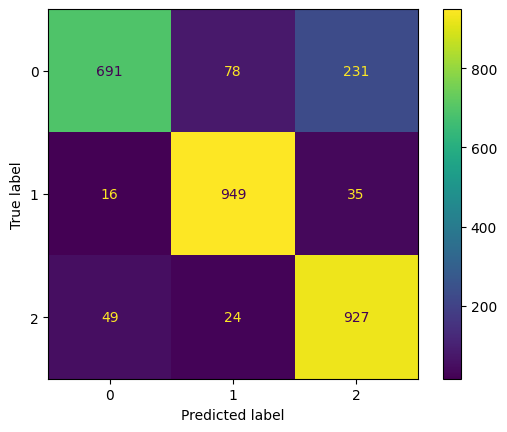

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


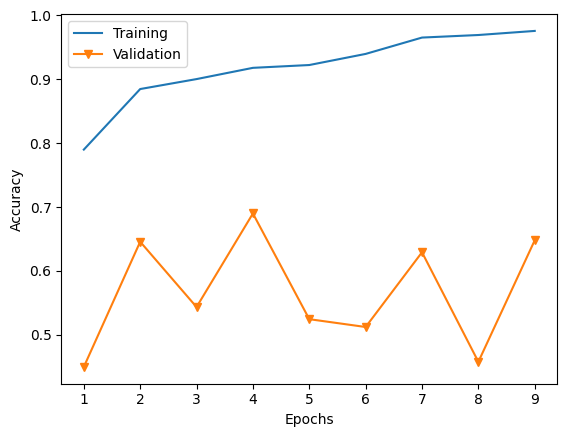

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.8233    0.6150    0.7041      1000
           1     0.9736    0.6640    0.7895      1000
           2     0.5410    0.7660    0.6341      1000
           3     0.5957    0.6880    0.6385      1000

    accuracy                         0.6833      4000
   macro avg     0.7334    0.6832    0.6916      4000
weighted avg     0.7334    0.6833    0.6916      4000



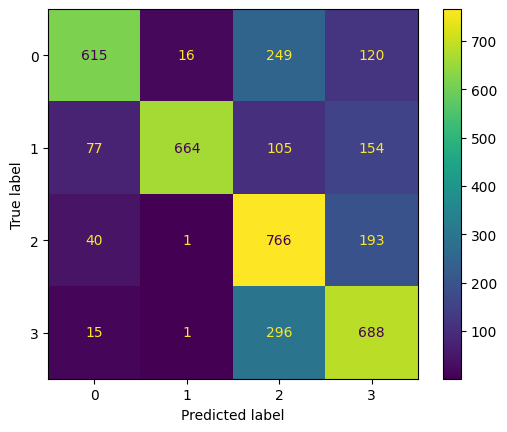

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


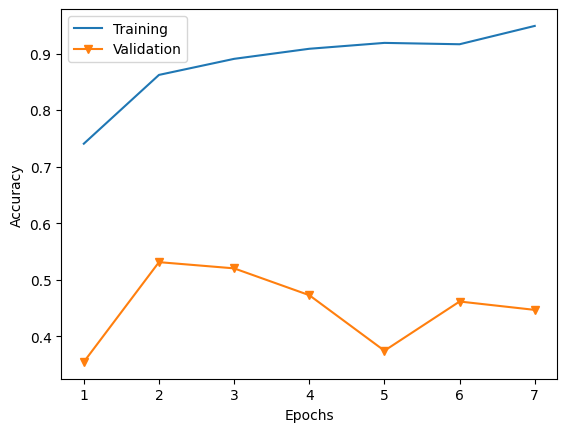

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.9039    0.4420    0.5937      1000
           1     0.7139    0.9680    0.8217      1000
           2     0.6628    0.2850    0.3986      1000
           3     0.9091    0.0200    0.0391      1000
           4     0.3492    0.9440    0.5099      1000

    accuracy                         0.5318      5000
   macro avg     0.7078    0.5318    0.4726      5000
weighted avg     0.7078    0.5318    0.4726      5000



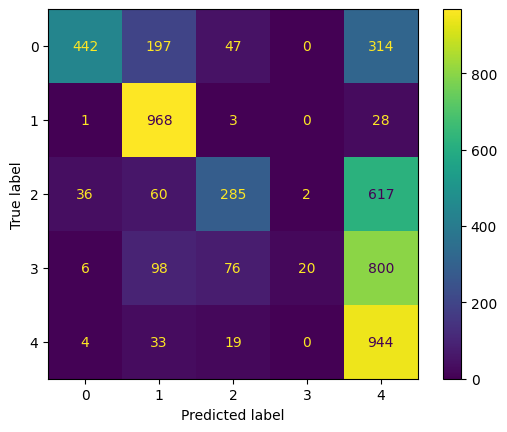

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 15.
Epoch 20: early stopping


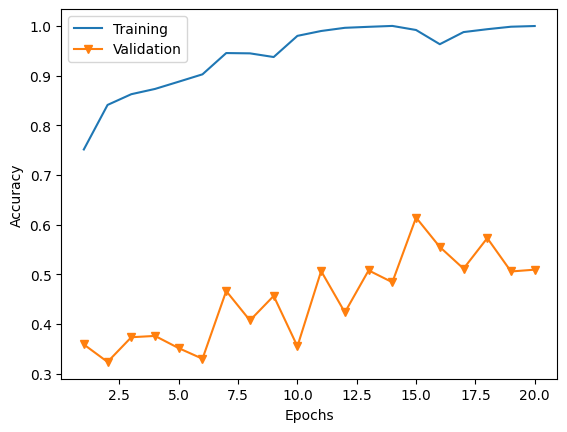

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8532    0.5810    0.6913      1000
           1     0.9166    0.7910    0.8492      1000
           2     0.5698    0.4000    0.4700      1000
           3     0.5248    0.1590    0.2441      1000
           4     0.4945    0.7650    0.6007      1000
           5     0.4280    0.8150    0.5613      1000

    accuracy                         0.5852      6000
   macro avg     0.6311    0.5852    0.5694      6000
weighted avg     0.6311    0.5852    0.5694      6000



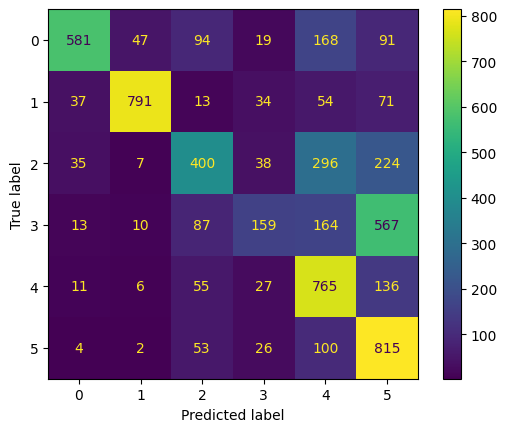

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 6.
Epoch 11: early stopping


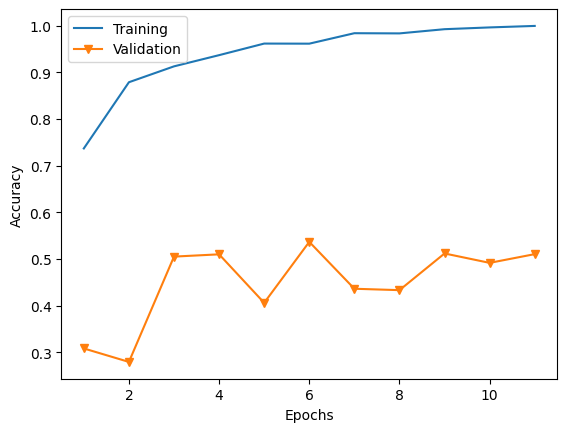

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8050    0.6730    0.7331      1000
           1     0.9024    0.8410    0.8706      1000
           2     0.4202    0.4420    0.4308      1000
           3     0.5195    0.2260    0.3150      1000
           4     0.6296    0.3230    0.4270      1000
           5     0.8952    0.0940    0.1701      1000
           6     0.3089    0.9660    0.4681      1000

    accuracy                         0.5093      7000
   macro avg     0.6401    0.5093    0.4878      7000
weighted avg     0.6401    0.5093    0.4878      7000



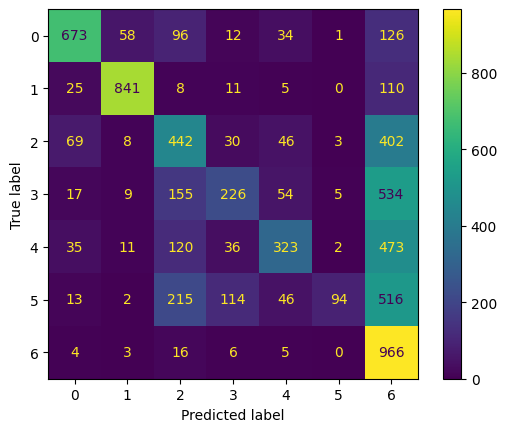

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


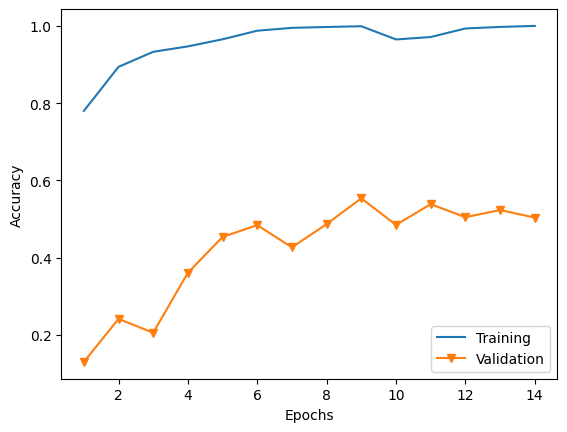

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8863    0.4910    0.6319      1000
           1     0.9402    0.7070    0.8071      1000
           2     0.6556    0.2970    0.4088      1000
           3     0.4594    0.3340    0.3868      1000
           4     0.6235    0.3180    0.4212      1000
           5     0.7017    0.3340    0.4526      1000
           6     0.4430    0.9010    0.5939      1000
           7     0.3677    0.9170    0.5249      1000

    accuracy                         0.5374      8000
   macro avg     0.6347    0.5374    0.5284      8000
weighted avg     0.6347    0.5374    0.5284      8000



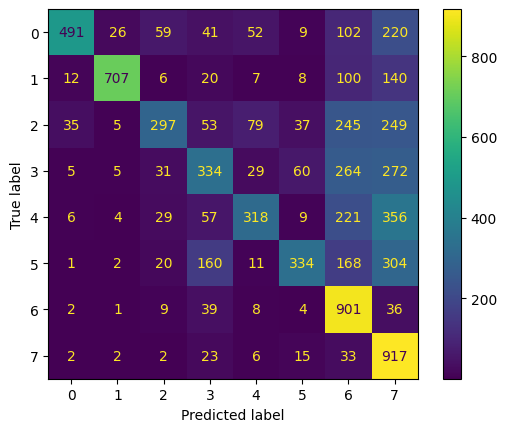

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 7.
Epoch 12: early stopping


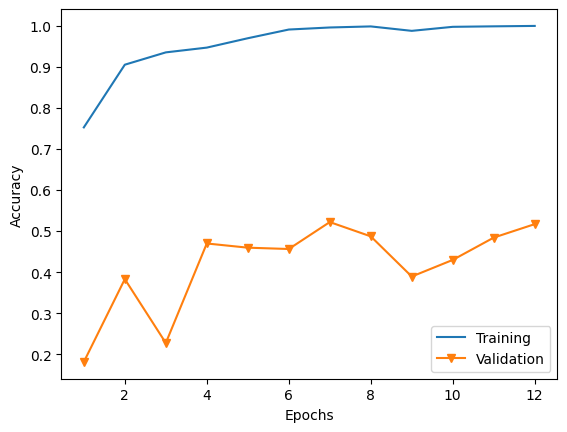

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.9077    0.1180    0.2088      1000
           1     0.9944    0.3530    0.5210      1000
           2     0.5832    0.4030    0.4766      1000
           3     0.3639    0.4920    0.4184      1000
           4     0.6199    0.4240    0.5036      1000
           5     0.4233    0.6210    0.5034      1000
           6     0.7633    0.5870    0.6637      1000
           7     0.8125    0.4810    0.6043      1000
           8     0.3291    0.9740    0.4919      1000

    accuracy                         0.4948      9000
   macro avg     0.6441    0.4948    0.4880      9000
weighted avg     0.6441    0.4948    0.4880      9000



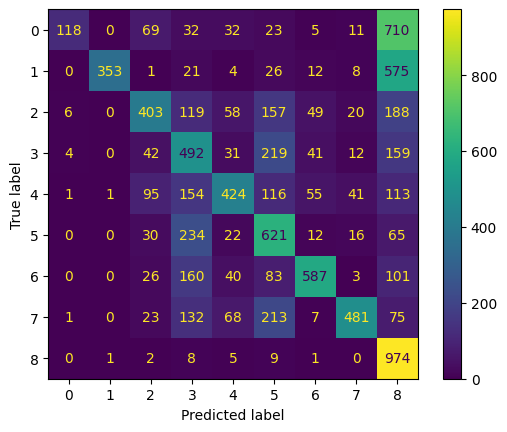

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 7.
Epoch 12: early stopping


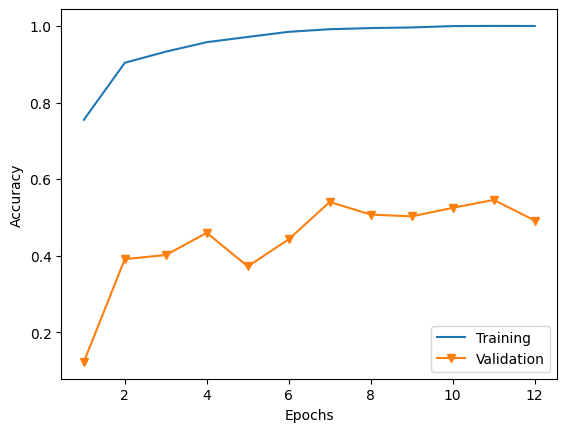

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8969    0.2870    0.4348      1000
           1     1.0000    0.0280    0.0545      1000
           2     0.5422    0.4750    0.5064      1000
           3     0.4289    0.3770    0.4013      1000
           4     0.6742    0.3870    0.4917      1000
           5     0.5055    0.6000    0.5487      1000
           6     0.5789    0.7700    0.6609      1000
           7     0.6719    0.6470    0.6592      1000
           8     0.6520    0.6670    0.6594      1000
           9     0.3369    0.9500    0.4974      1000

    accuracy                         0.5188     10000
   macro avg     0.6287    0.5188    0.4914     10000
weighted avg     0.6287    0.5188    0.4914     10000



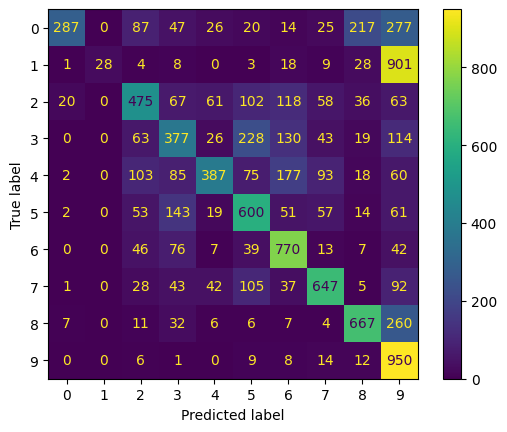

---------------------------------------------------------------------------



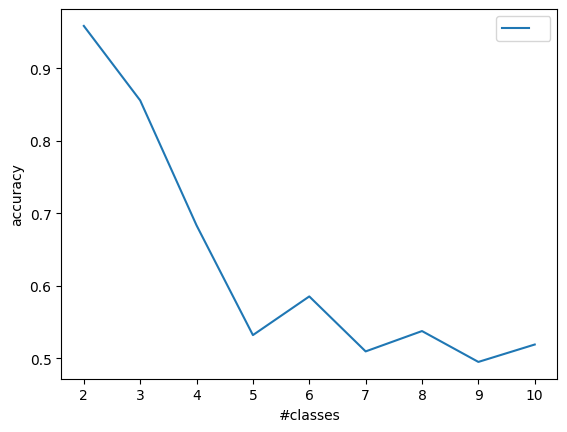

In [3]:
acc_list7 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    load_dataset_fn_kwargs={"preprocess": "min-max"}, 
    remove_prev_classes=True, 
    keep_same_model=True, 
    tuned_model_path=TUNED_CNN_MODEL_PATH, 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS, 
    use_buffer=True,
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


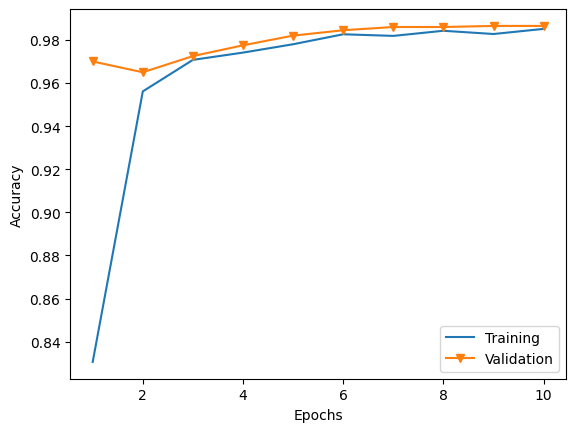

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9735    0.9930    0.9832      1000
           1     0.9929    0.9730    0.9828      1000

    accuracy                         0.9830      2000
   macro avg     0.9832    0.9830    0.9830      2000
weighted avg     0.9832    0.9830    0.9830      2000



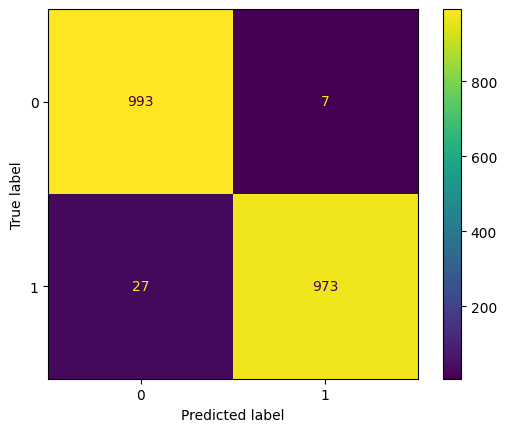

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


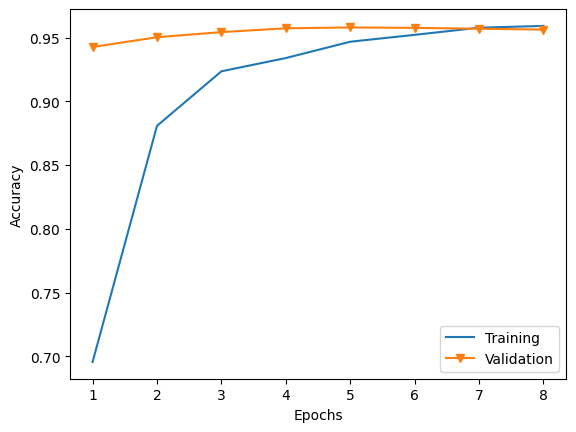

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9562    0.8960    0.9251      1000
           1     0.9869    0.9800    0.9834      1000
           2     0.9121    0.9760    0.9430      1000

    accuracy                         0.9507      3000
   macro avg     0.9518    0.9507    0.9505      3000
weighted avg     0.9518    0.9507    0.9505      3000



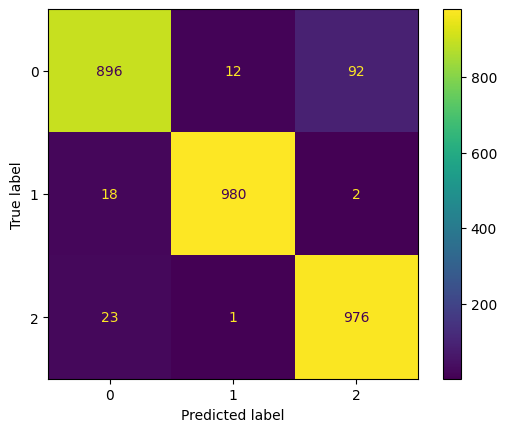

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


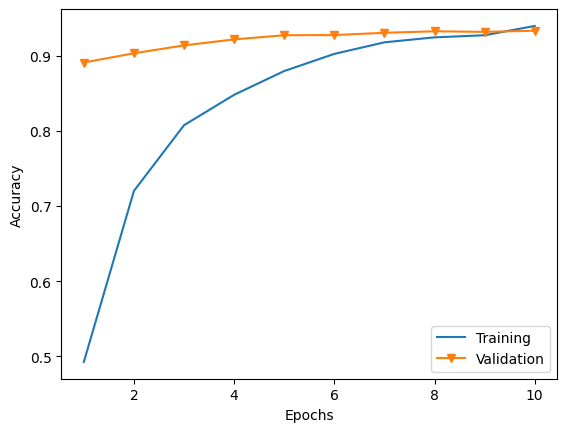

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9520    0.8920    0.9210      1000
           1     0.9587    0.9760    0.9673      1000
           2     0.8770    0.8630    0.8700      1000
           3     0.8633    0.9160    0.8889      1000

    accuracy                         0.9117      4000
   macro avg     0.9128    0.9117    0.9118      4000
weighted avg     0.9128    0.9117    0.9118      4000



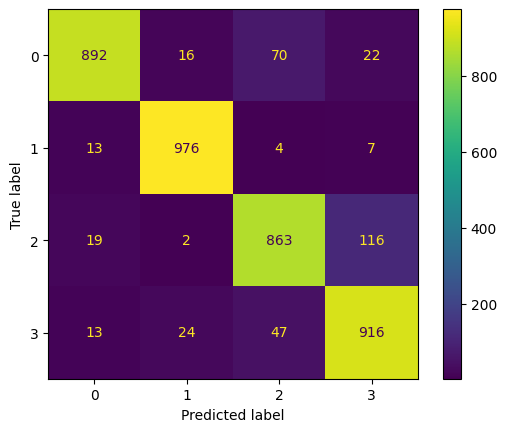

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


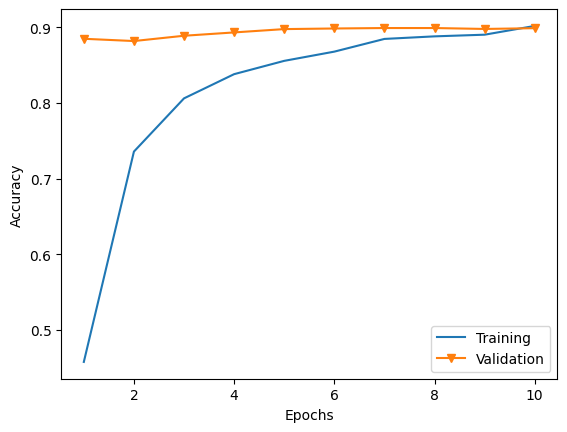

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9333    0.8950    0.9137      1000
           1     0.9669    0.9630    0.9649      1000
           2     0.8958    0.7740    0.8305      1000
           3     0.8031    0.8850    0.8421      1000
           4     0.8323    0.8980    0.8639      1000

    accuracy                         0.8830      5000
   macro avg     0.8863    0.8830    0.8830      5000
weighted avg     0.8863    0.8830    0.8830      5000



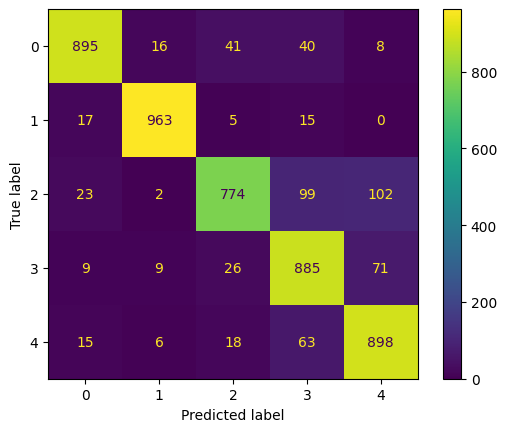

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


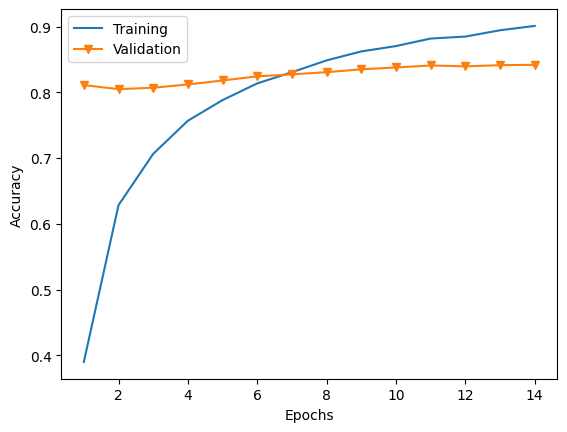

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9388    0.9050    0.9216      1000
           1     0.9728    0.9650    0.9689      1000
           2     0.9227    0.7760    0.8430      1000
           3     0.7754    0.4970    0.6057      1000
           4     0.7890    0.9160    0.8478      1000
           5     0.6410    0.8980    0.7480      1000

    accuracy                         0.8262      6000
   macro avg     0.8399    0.8262    0.8225      6000
weighted avg     0.8399    0.8262    0.8225      6000



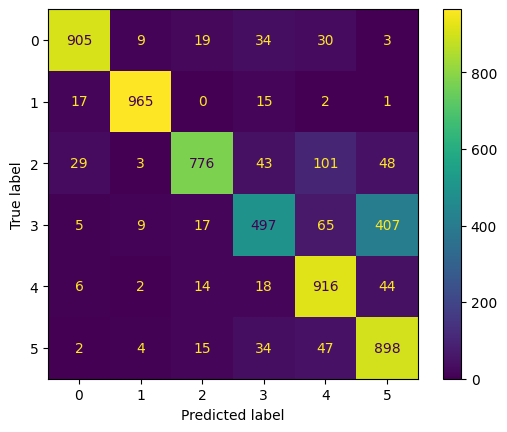

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


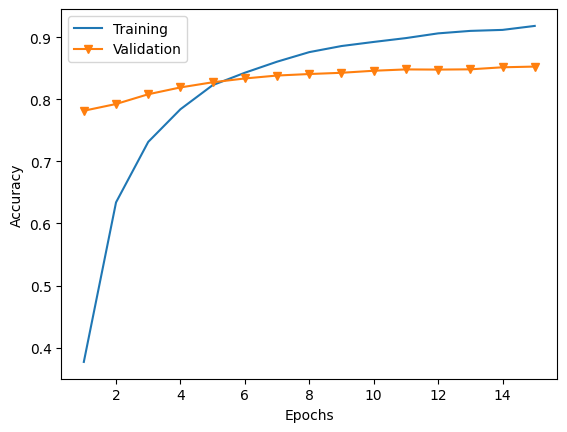

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9260    0.9130    0.9194      1000
           1     0.9633    0.9720    0.9676      1000
           2     0.8919    0.7670    0.8247      1000
           3     0.7972    0.5780    0.6701      1000
           4     0.8929    0.8250    0.8576      1000
           5     0.6929    0.8820    0.7761      1000
           6     0.7433    0.9090    0.8178      1000

    accuracy                         0.8351      7000
   macro avg     0.8439    0.8351    0.8333      7000
weighted avg     0.8439    0.8351    0.8333      7000



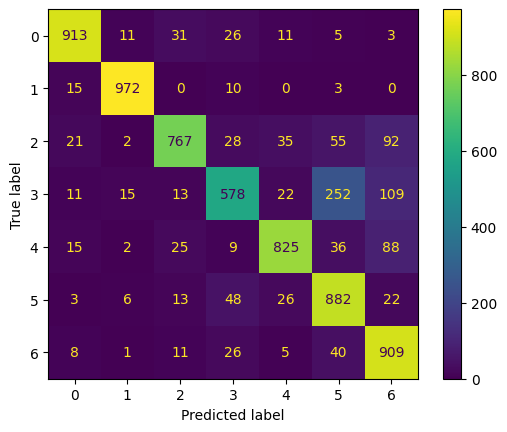

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 13.
Epoch 18: early stopping


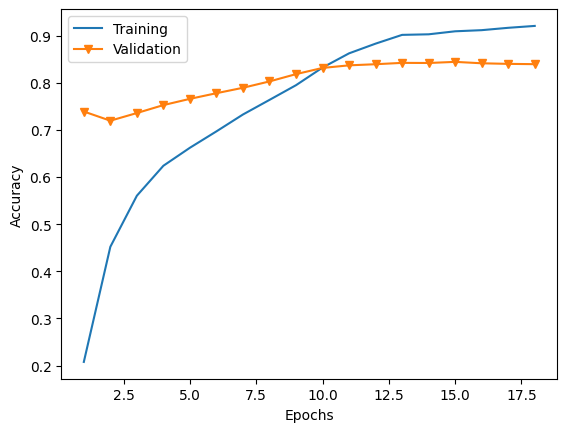

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9306    0.8710    0.8998      1000
           1     0.9798    0.9680    0.9738      1000
           2     0.9289    0.7320    0.8188      1000
           3     0.7605    0.6730    0.7141      1000
           4     0.7955    0.7470    0.7705      1000
           5     0.8552    0.7680    0.8093      1000
           6     0.6951    0.9280    0.7949      1000
           7     0.7522    0.9260    0.8301      1000

    accuracy                         0.8266      8000
   macro avg     0.8372    0.8266    0.8264      8000
weighted avg     0.8372    0.8266    0.8264      8000



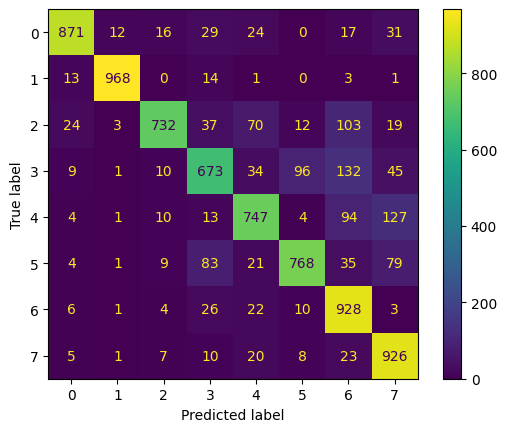

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


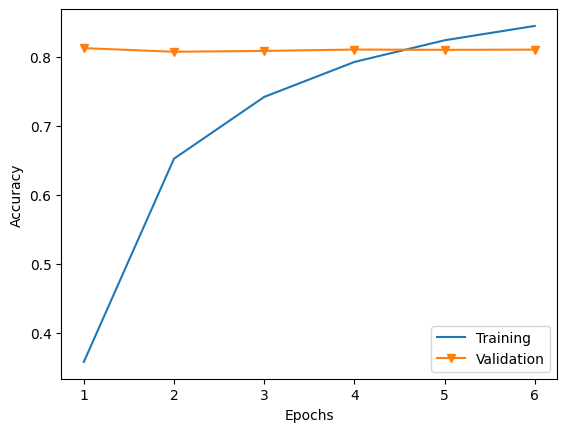

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9264    0.6040    0.7312      1000
           1     0.9454    0.9690    0.9570      1000
           2     0.9289    0.7060    0.8023      1000
           3     0.7398    0.7050    0.7220      1000
           4     0.8477    0.7180    0.7775      1000
           5     0.8418    0.7770    0.8081      1000
           6     0.6982    0.9300    0.7976      1000
           7     0.6736    0.9410    0.7851      1000
           8     0.7624    0.8470    0.8025      1000

    accuracy                         0.7997      9000
   macro avg     0.8182    0.7997    0.7981      9000
weighted avg     0.8182    0.7997    0.7981      9000



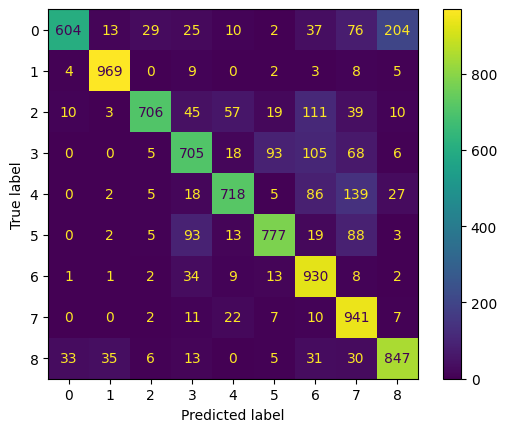

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 9.
Epoch 14: early stopping


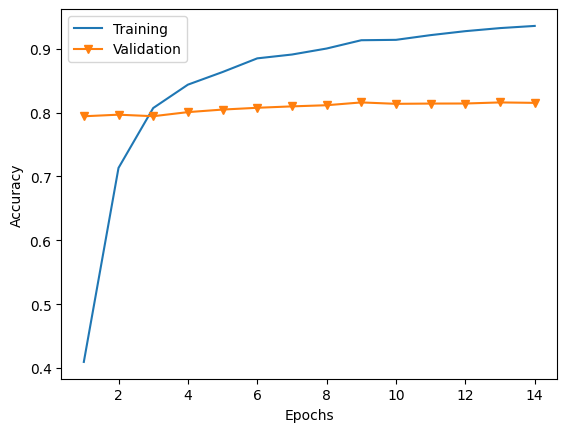

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8864    0.7260    0.7982      1000
           1     0.9821    0.5500    0.7051      1000
           2     0.8685    0.8060    0.8361      1000
           3     0.7569    0.6540    0.7017      1000
           4     0.8254    0.8130    0.8191      1000
           5     0.8121    0.8080    0.8100      1000
           6     0.7949    0.9110    0.8490      1000
           7     0.7809    0.9090    0.8401      1000
           8     0.8659    0.8330    0.8491      1000
           9     0.6100    0.9620    0.7466      1000

    accuracy                         0.7972     10000
   macro avg     0.8183    0.7972    0.7955     10000
weighted avg     0.8183    0.7972    0.7955     10000



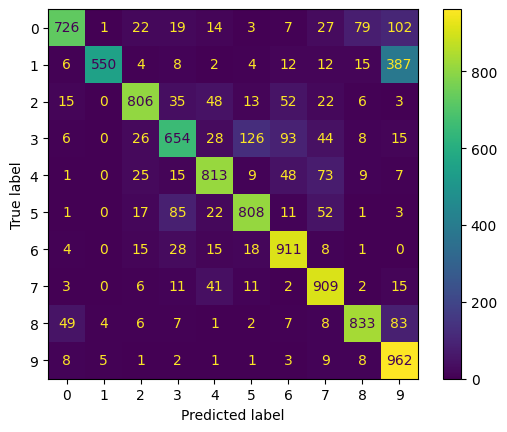

---------------------------------------------------------------------------



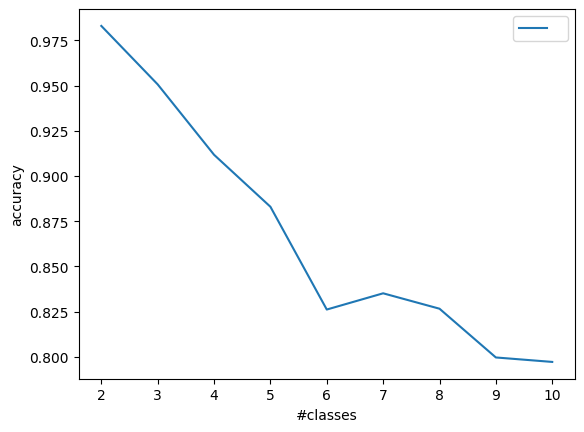

In [4]:
from tensorflow.keras import optimizers

from masked_loss import MaskedLoss
from model import get_compile_args


acc_list8 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    load_dataset_fn_kwargs={"onehot_labels": True}, 
    remove_prev_classes=True, 
    keep_same_model=True, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    compile_args=get_compile_args(
        optimizer=optimizers.Adam(learning_rate=5e-5), 
        loss=MaskedLoss()
    ),
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS, 
    use_buffer=True,
)

## Continually adding classes to the same model without the previous data but with VAE

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Epoch 1/100
63/63 [==============================] - 3s 15ms/step - loss: 0.1711 - accuracy: 0.8701 - val_loss: 0.2350 - val_accuracy: 0.9155
Epoch 2/100
63/63 [==============================] - 1s 11ms/step - loss: 0.0559 - accuracy: 0.9635 - val_loss: 0.1444 - val_accuracy: 0.9435
Epoch 3/100
63/63 [==============================] - 1s 11ms/step - loss: 0.0413 - accuracy: 0.9726 - val_loss: 0.0879 - val_accuracy: 0.9605
Epoch 4/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0360 - accuracy: 0.9760 - val_loss: 0.0535 - val_accuracy: 0.9730
Epoch 5/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0298 - accuracy: 0.9789 - val_loss: 0.0365 - val_accuracy: 0.9805
Epoch 6/100
63/63 [==============================] - 1s 10ms/step - loss: 0.0285 - accuracy: 0.9806 - val_loss: 0.0269 - val_accuracy: 0.9850
Epoch 7/100
63/63 [==============================] - 1s 

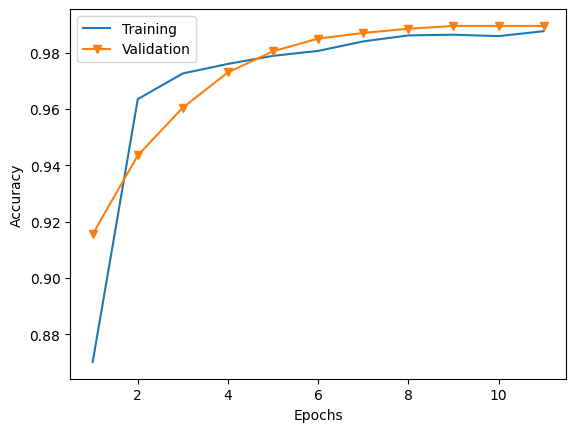

Epoch 1/10
2/2 [==============================] - 2s 717ms/step - loss: 2.2248 - recon_loss: 0.1440 - kl_loss: 7.9874 - val_loss: 9.8016 - val_recon_loss: 0.1825 - val_kl_loss: 38.4765 - decoder_accuracy: 0.8170
Epoch 2/10
2/2 [==============================] - 0s 331ms/step - loss: 0.3876 - recon_loss: 0.0605 - kl_loss: 1.1578 - val_loss: 4.0086 - val_recon_loss: 0.0611 - val_kl_loss: 15.7902 - decoder_accuracy: 0.9010
Epoch 3/10
2/2 [==============================] - 0s 311ms/step - loss: 0.1397 - recon_loss: 0.0381 - kl_loss: 0.3919 - val_loss: 3.2363 - val_recon_loss: 0.0521 - val_kl_loss: 12.7367 - decoder_accuracy: 0.9470
Epoch 4/10
2/2 [==============================] - 0s 330ms/step - loss: 0.1136 - recon_loss: 0.0372 - kl_loss: 0.3023 - val_loss: 2.3851 - val_recon_loss: 0.0406 - val_kl_loss: 9.3781 - decoder_accuracy: 0.9420
Epoch 5/10
2/2 [==============================] - 0s 352ms/step - loss: 0.0853 - recon_loss: 0.0323 - kl_loss: 0.2010 - val_loss: 1.5848 - val_recon_loss

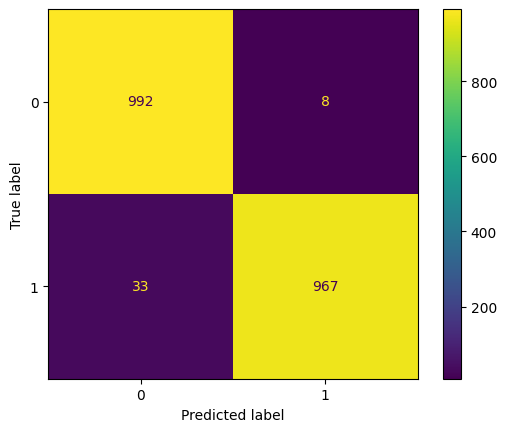

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
63/63 [==============================] - 0s 3ms/step
Epoch 1/100
47/47 [==============================] - 2s 17ms/step - loss: 0.1022 - accuracy: 0.8662 - val_loss: 0.0821 - val_accuracy: 0.8950
Epoch 2/100
47/47 [==============================] - 0s 10ms/step - loss: 0.0109 - accuracy: 0.9932 - val_loss: 0.1114 - val_accuracy: 0.8493
Epoch 3/100
47/47 [==============================] - 0s 10ms/step - loss: 0.0052 - accuracy: 0.9983 - val_loss: 0.1228 - val_accuracy: 0.8270
Epoch 4/100
47/47 [==============================] - 0s 10ms/step - loss: 0.0041 - accuracy: 0.9983 - val_loss: 0.1349 - val_accuracy: 0.8040
Epoch 5/100
47/47 [==============================] - 0s 10ms/step - loss: 0.0033 - accuracy: 0.9993 - val_loss: 0.1469 - val_accuracy: 0.7837
Epoch 6/100
47/47 [==============================] - 0s 10ms/step

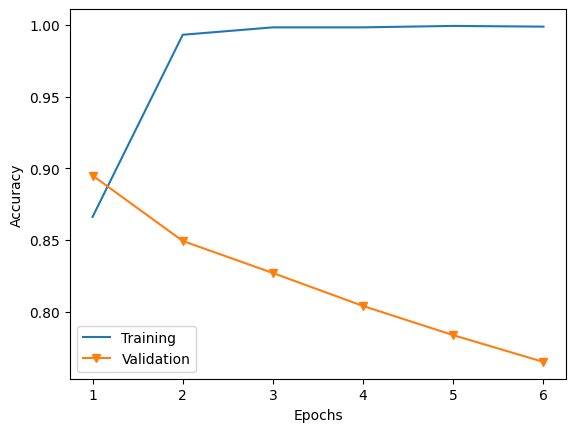

Epoch 1/10
2/2 [==============================] - 1s 696ms/step - loss: 0.0388 - recon_loss: 0.0272 - kl_loss: 0.0430 - val_loss: 0.2157 - val_recon_loss: 0.0319 - val_kl_loss: 0.7351 - decoder_accuracy: 0.8716
Epoch 2/10
2/2 [==============================] - 1s 531ms/step - loss: 0.0370 - recon_loss: 0.0233 - kl_loss: 0.0570 - val_loss: 0.2113 - val_recon_loss: 0.0314 - val_kl_loss: 0.7196 - decoder_accuracy: 0.9196
Epoch 3/10
2/2 [==============================] - 1s 521ms/step - loss: 0.0479 - recon_loss: 0.0226 - kl_loss: 0.1056 - val_loss: 0.2294 - val_recon_loss: 0.0309 - val_kl_loss: 0.7937 - decoder_accuracy: 0.9980
Epoch 4/10
2/2 [==============================] - 1s 521ms/step - loss: 0.0549 - recon_loss: 0.0225 - kl_loss: 0.1269 - val_loss: 0.1696 - val_recon_loss: 0.0308 - val_kl_loss: 0.5553 - decoder_accuracy: 0.9984
Epoch 5/10
2/2 [==============================] - 1s 537ms/step - loss: 0.0416 - recon_loss: 0.0224 - kl_loss: 0.0705 - val_loss: 0.1046 - val_recon_loss: 0

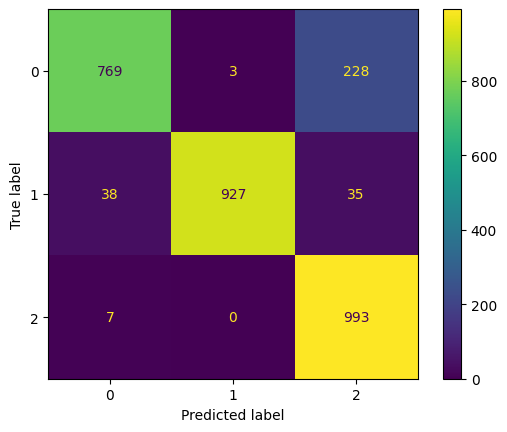

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
157/157 [==============================] - 0s 2ms/step
Epoch 1/100
71/71 [==============================] - 2s 13ms/step - loss: 0.0427 - accuracy: 0.9231 - val_loss: 0.0879 - val_accuracy: 0.8397
Epoch 2/100
71/71 [==============================] - 1s 11ms/step - loss: 0.0025 - accuracy: 0.9987 - val_loss: 0.0976 - val_accuracy: 0.8115
Epoch 3/100
71/71 [==============================] - 1s 11ms/step - loss: 0.0016 - accuracy: 0.9991 - val_loss: 0.1052 - val_accuracy: 0.7960
Epoch 4/100
71/71 [==============================] - 1s 11ms/step - loss: 0.0013 - accuracy: 0.9991 - val_loss: 0.1130 - val_accuracy: 0.7795
Epoch 5/100
71/71 [==============================] - 1s 11ms/step - loss: 9.8366e-04 - accuracy: 0.9994 - val_loss: 0.1191 - val_accuracy: 0.7678
Epoch 6/100
71/71 [==============================] - 1s 

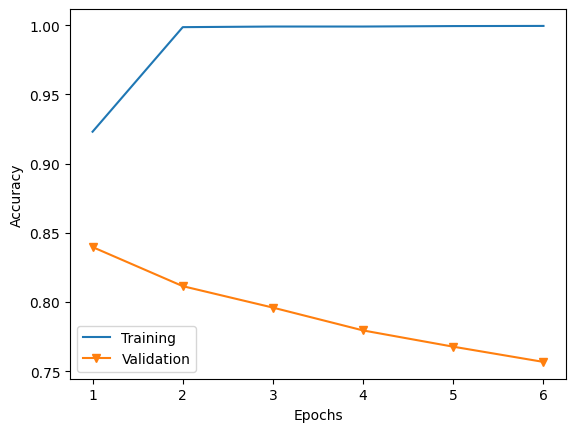

Epoch 1/10
2/2 [==============================] - 1s 964ms/step - loss: 0.0503 - recon_loss: 0.0169 - kl_loss: 0.1343 - val_loss: 0.1712 - val_recon_loss: 0.0322 - val_kl_loss: 0.5561 - decoder_accuracy: 0.9900
Epoch 2/10
2/2 [==============================] - 1s 800ms/step - loss: 0.0389 - recon_loss: 0.0158 - kl_loss: 0.0871 - val_loss: 0.1093 - val_recon_loss: 0.0321 - val_kl_loss: 0.3088 - decoder_accuracy: 1.0000
Epoch 3/10
2/2 [==============================] - 1s 820ms/step - loss: 0.0247 - recon_loss: 0.0162 - kl_loss: 0.0319 - val_loss: 0.0835 - val_recon_loss: 0.0324 - val_kl_loss: 0.2044 - decoder_accuracy: 0.9996
Epoch 4/10
2/2 [==============================] - 1s 823ms/step - loss: 0.0203 - recon_loss: 0.0162 - kl_loss: 0.0178 - val_loss: 0.0736 - val_recon_loss: 0.0324 - val_kl_loss: 0.1648 - decoder_accuracy: 1.0000
Epoch 5/10
2/2 [==============================] - 1s 886ms/step - loss: 0.0190 - recon_loss: 0.0155 - kl_loss: 0.0148 - val_loss: 0.0673 - val_recon_loss: 0

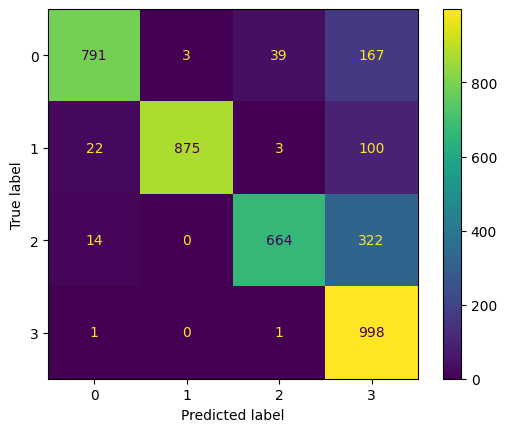

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
282/282 [==============================] - 1s 2ms/step
Epoch 1/100
102/102 [==============================] - 2s 13ms/step - loss: 0.0285 - accuracy: 0.9370 - val_loss: 0.1055 - val_accuracy: 0.7484
Epoch 2/100
102/102 [==============================] - 1s 9ms/step - loss: 0.0019 - accuracy: 0.9982 - val_loss: 0.1296 - val_accuracy: 0.6798
Epoch 3/100
102/102 [==============================] - 1s 9ms/step - loss: 9.3295e-04 - accuracy: 0.9996 - val_loss: 0.1442 - val_accuracy: 0.6416
Epoch 4/100
102/102 [==============================] - 1s 10ms/step - loss: 7.9022e-04 - accuracy: 0.9994 - val_loss: 0.1517 - val_accuracy: 0.6220
Epoch 5/100
102/102 [==============================] - 1s 10ms/step - loss: 5.9653e-04 - accuracy: 1.0000 - val_loss: 0.1552 - val_accuracy: 0.6148
Epoch 6/100
102/102 [================

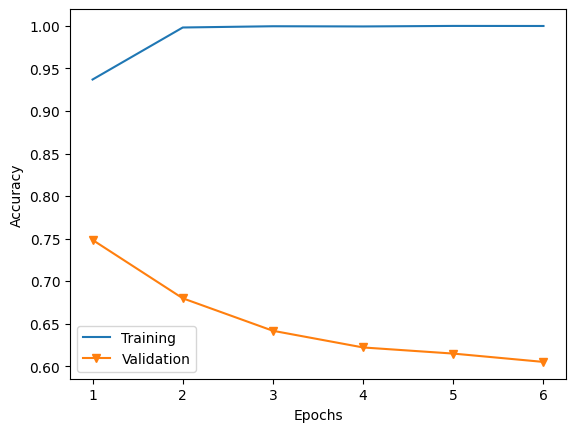

Epoch 1/10
2/2 [==============================] - 1s 1s/step - loss: 0.0497 - recon_loss: 0.0110 - kl_loss: 0.1700 - val_loss: 0.2132 - val_recon_loss: 0.0323 - val_kl_loss: 0.7236 - decoder_accuracy: 0.9193
Epoch 2/10
2/2 [==============================] - 1s 1s/step - loss: 0.0624 - recon_loss: 0.0100 - kl_loss: 0.2024 - val_loss: 0.1255 - val_recon_loss: 0.0328 - val_kl_loss: 0.3708 - decoder_accuracy: 0.8517
Epoch 3/10
2/2 [==============================] - 1s 1s/step - loss: 0.0273 - recon_loss: 0.0101 - kl_loss: 0.0596 - val_loss: 0.0707 - val_recon_loss: 0.0323 - val_kl_loss: 0.1535 - decoder_accuracy: 0.8844
Epoch 4/10
2/2 [==============================] - 1s 1s/step - loss: 0.0128 - recon_loss: 0.0097 - kl_loss: 0.0122 - val_loss: 0.0599 - val_recon_loss: 0.0316 - val_kl_loss: 0.1133 - decoder_accuracy: 0.9860
Epoch 5/10
2/2 [==============================] - 1s 1s/step - loss: 0.0112 - recon_loss: 0.0094 - kl_loss: 0.0070 - val_loss: 0.0550 - val_recon_loss: 0.0318 - val_kl_

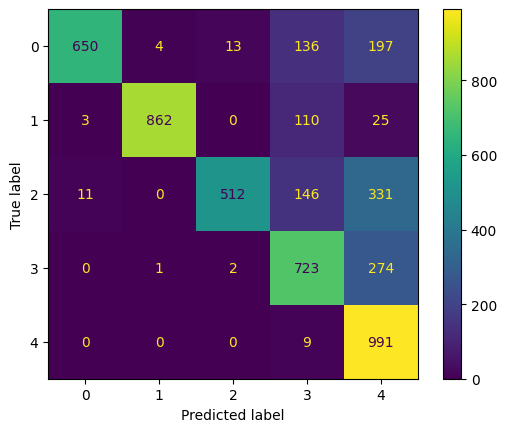

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
438/438 [==============================] - 1s 2ms/step
Epoch 1/100
141/141 [==============================] - 2s 11ms/step - loss: 0.0094 - accuracy: 0.9763 - val_loss: 0.1344 - val_accuracy: 0.6027
Epoch 2/100
141/141 [==============================] - 1s 11ms/step - loss: 5.4113e-04 - accuracy: 0.9998 - val_loss: 0.1455 - val_accuracy: 0.5705
Epoch 3/100
141/141 [==============================] - 1s 10ms/step - loss: 3.5368e-04 - accuracy: 0.9999 - val_loss: 0.1508 - val_accuracy: 0.5535
Epoch 4/100
141/141 [==============================] - 1s 9ms/step - loss: 2.9205e-04 - accuracy: 0.9999 - val_loss: 0.1538 - val_accuracy: 0.5442
Epoch 5/100
141/141 [==============================] - 1s 9ms/step - loss: 2.3670e-04 - accuracy: 0.9998 - val_loss: 0.1562 - val_accuracy: 0.5378
Epoch 6/100
141/141 [=========

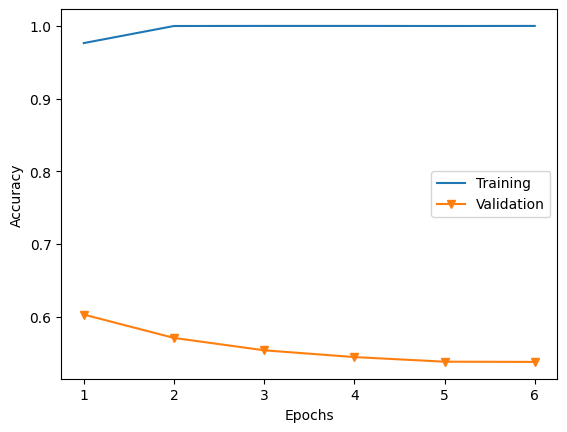

Epoch 1/10
2/2 [==============================] - 2s 2s/step - loss: 0.0108 - recon_loss: 0.0090 - kl_loss: 0.0064 - val_loss: 0.0521 - val_recon_loss: 0.0331 - val_kl_loss: 0.0758 - decoder_accuracy: 0.9639
Epoch 2/10
2/2 [==============================] - 2s 2s/step - loss: 0.0103 - recon_loss: 0.0088 - kl_loss: 0.0060 - val_loss: 0.0507 - val_recon_loss: 0.0345 - val_kl_loss: 0.0648 - decoder_accuracy: 0.9846
Epoch 3/10
2/2 [==============================] - 2s 2s/step - loss: 0.0110 - recon_loss: 0.0098 - kl_loss: 0.0059 - val_loss: 0.0500 - val_recon_loss: 0.0357 - val_kl_loss: 0.0573 - decoder_accuracy: 0.9569
Epoch 4/10
2/2 [==============================] - 2s 2s/step - loss: 0.0115 - recon_loss: 0.0098 - kl_loss: 0.0059 - val_loss: 0.0486 - val_recon_loss: 0.0358 - val_kl_loss: 0.0510 - decoder_accuracy: 0.9436
Epoch 5/10
2/2 [==============================] - 2s 2s/step - loss: 0.0109 - recon_loss: 0.0092 - kl_loss: 0.0058 - val_loss: 0.0456 - val_recon_loss: 0.0343 - val_kl_

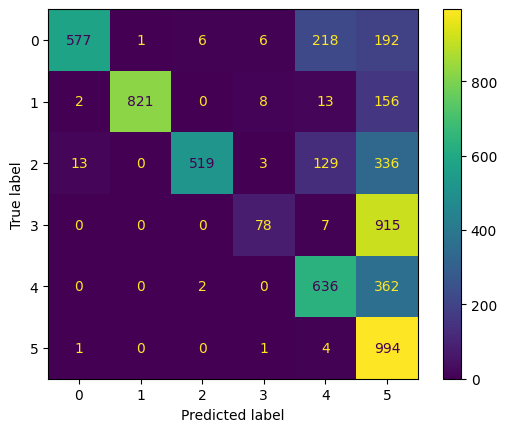

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
625/625 [==============================] - 1s 2ms/step
Epoch 1/100
188/188 [==============================] - 3s 11ms/step - loss: 0.0042 - accuracy: 0.9870 - val_loss: 0.1423 - val_accuracy: 0.5063
Epoch 2/100
188/188 [==============================] - 2s 9ms/step - loss: 2.6129e-04 - accuracy: 0.9997 - val_loss: 0.1497 - val_accuracy: 0.4773
Epoch 3/100
188/188 [==============================] - 2s 9ms/step - loss: 1.6466e-04 - accuracy: 0.9998 - val_loss: 0.1574 - val_accuracy: 0.4511
Epoch 4/100
188/188 [==============================] - 2s 9ms/step - loss: 1.0698e-04 - accuracy: 1.0000 - val_loss: 0.1594 - val_accuracy: 0.4434
Epoch 5/100
188/188 [==============================] - 2s 9ms/step - loss: 8.6786e-05 - accuracy: 1.0000 - val_loss: 0.1624 - val_accuracy: 0.4333
Epoch 6/100
188/188 [========

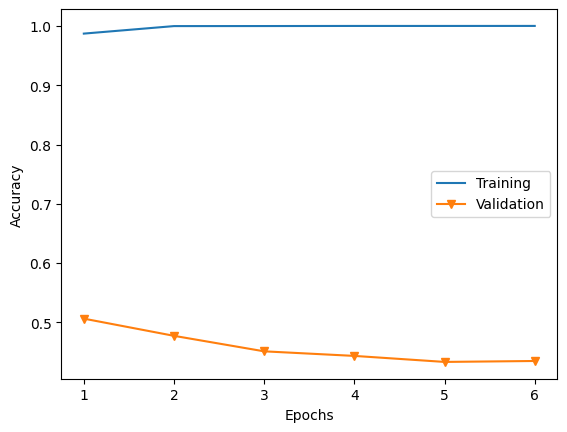

Epoch 1/10
2/2 [==============================] - 2s 2s/step - loss: 0.0087 - recon_loss: 0.0072 - kl_loss: 0.0057 - val_loss: 0.0480 - val_recon_loss: 0.0377 - val_kl_loss: 0.0408 - decoder_accuracy: 0.9584
Epoch 2/10
2/2 [==============================] - 2s 2s/step - loss: 0.0102 - recon_loss: 0.0089 - kl_loss: 0.0059 - val_loss: 0.0491 - val_recon_loss: 0.0398 - val_kl_loss: 0.0371 - decoder_accuracy: 0.7804
Epoch 3/10
2/2 [==============================] - 2s 2s/step - loss: 0.0109 - recon_loss: 0.0095 - kl_loss: 0.0061 - val_loss: 0.0572 - val_recon_loss: 0.0485 - val_kl_loss: 0.0345 - decoder_accuracy: 0.5550
Epoch 4/10
2/2 [==============================] - 2s 2s/step - loss: 0.0170 - recon_loss: 0.0152 - kl_loss: 0.0060 - val_loss: 0.0877 - val_recon_loss: 0.0798 - val_kl_loss: 0.0316 - decoder_accuracy: 0.6393
Epoch 5/10
2/2 [==============================] - 2s 2s/step - loss: 0.0715 - recon_loss: 0.0857 - kl_loss: 0.0055 - val_loss: 0.7944 - val_recon_loss: 0.7865 - val_kl_

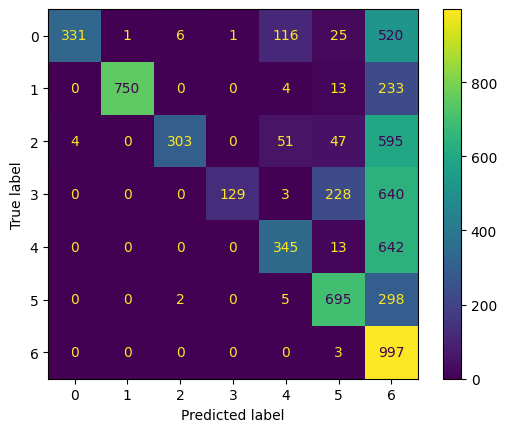

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
844/844 [==============================] - 1s 2ms/step
Epoch 1/100
243/243 [==============================] - 3s 10ms/step - loss: 0.0044 - accuracy: 0.9842 - val_loss: 0.1246 - val_accuracy: 0.5035
Epoch 2/100
243/243 [==============================] - 2s 9ms/step - loss: 2.6998e-04 - accuracy: 0.9998 - val_loss: 0.1304 - val_accuracy: 0.4794
Epoch 3/100
243/243 [==============================] - 2s 9ms/step - loss: 1.5261e-04 - accuracy: 1.0000 - val_loss: 0.1328 - val_accuracy: 0.4685
Epoch 4/100
243/243 [==============================] - 2s 9ms/step - loss: 1.0555e-04 - accuracy: 1.0000 - val_loss: 0.1377 - val_accuracy: 0.4523
Epoch 5/100
243/243 [==============================] - 2s 9ms/step - loss: 9.5212e-05 - accuracy: 0.9999 - val_loss: 0.1367 - val_accuracy: 0.4551
Epoch 6/100
243/243 [=====

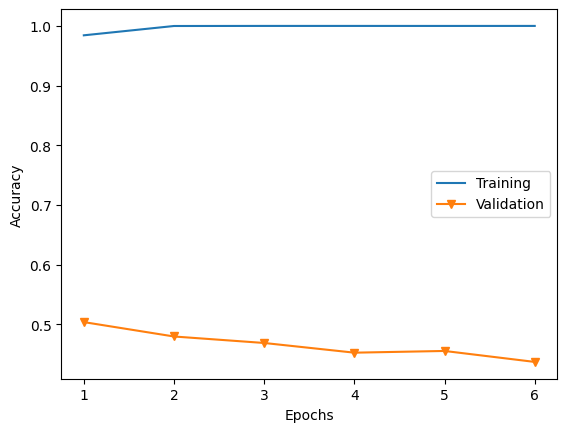

Epoch 1/10
2/2 [==============================] - 3s 3s/step - loss: 0.0088 - recon_loss: 0.0067 - kl_loss: 0.0071 - val_loss: 0.0510 - val_recon_loss: 0.0413 - val_kl_loss: 0.0391 - decoder_accuracy: 0.9936
Epoch 2/10
2/2 [==============================] - 3s 3s/step - loss: 0.0081 - recon_loss: 0.0063 - kl_loss: 0.0071 - val_loss: 0.0497 - val_recon_loss: 0.0405 - val_kl_loss: 0.0369 - decoder_accuracy: 0.9980
Epoch 3/10
2/2 [==============================] - 3s 3s/step - loss: 0.0071 - recon_loss: 0.0055 - kl_loss: 0.0070 - val_loss: 0.0476 - val_recon_loss: 0.0389 - val_kl_loss: 0.0347 - decoder_accuracy: 0.9974
Epoch 4/10
2/2 [==============================] - 3s 3s/step - loss: 0.0066 - recon_loss: 0.0049 - kl_loss: 0.0067 - val_loss: 0.0463 - val_recon_loss: 0.0381 - val_kl_loss: 0.0328 - decoder_accuracy: 0.9980
Epoch 5/10
2/2 [==============================] - 3s 3s/step - loss: 0.0062 - recon_loss: 0.0047 - kl_loss: 0.0062 - val_loss: 0.0452 - val_recon_loss: 0.0374 - val_kl_

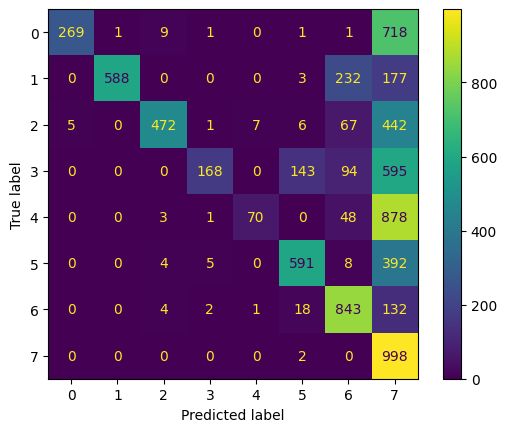

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
1094/1094 [==============================] - 2s 2ms/step
Epoch 1/100
305/305 [==============================] - 4s 10ms/step - loss: 0.0014 - accuracy: 0.9956 - val_loss: 0.1110 - val_accuracy: 0.5068
Epoch 2/100
305/305 [==============================] - 3s 9ms/step - loss: 1.4297e-04 - accuracy: 0.9999 - val_loss: 0.1152 - val_accuracy: 0.4861
Epoch 3/100
305/305 [==============================] - 3s 9ms/step - loss: 9.2669e-05 - accuracy: 1.0000 - val_loss: 0.1165 - val_accuracy: 0.4787
Epoch 4/100
305/305 [==============================] - 3s 9ms/step - loss: 6.7733e-05 - accuracy: 0.9999 - val_loss: 0.1162 - val_accuracy: 0.4790
Epoch 5/100
305/305 [==============================] - 3s 9ms/step - loss: 4.1236e-05 - accuracy: 1.0000 - val_loss: 0.1174 - val_accuracy: 0.4756
Epoch 6/100
305/305 [

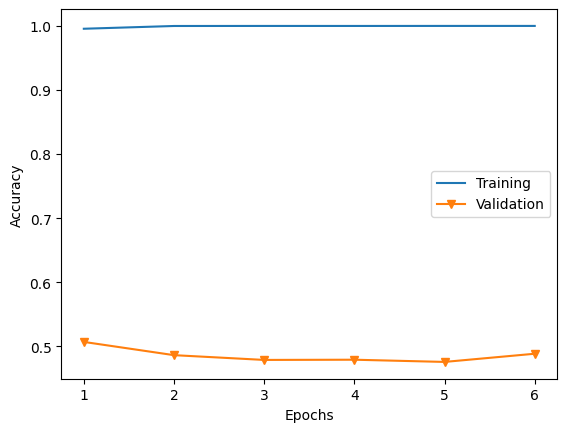

Epoch 1/10
2/2 [==============================] - 4s 4s/step - loss: 0.0079 - recon_loss: 0.0058 - kl_loss: 0.0082 - val_loss: 0.0500 - val_recon_loss: 0.0410 - val_kl_loss: 0.0361 - decoder_accuracy: 0.9834
Epoch 2/10
2/2 [==============================] - 3s 3s/step - loss: 0.0072 - recon_loss: 0.0051 - kl_loss: 0.0082 - val_loss: 0.0512 - val_recon_loss: 0.0427 - val_kl_loss: 0.0341 - decoder_accuracy: 0.9992
Epoch 3/10
2/2 [==============================] - 3s 3s/step - loss: 0.0069 - recon_loss: 0.0048 - kl_loss: 0.0079 - val_loss: 0.0519 - val_recon_loss: 0.0439 - val_kl_loss: 0.0321 - decoder_accuracy: 0.9998
Epoch 4/10
2/2 [==============================] - 3s 3s/step - loss: 0.0062 - recon_loss: 0.0045 - kl_loss: 0.0072 - val_loss: 0.0498 - val_recon_loss: 0.0425 - val_kl_loss: 0.0294 - decoder_accuracy: 1.0000
Epoch 5/10
2/2 [==============================] - 3s 3s/step - loss: 0.0057 - recon_loss: 0.0041 - kl_loss: 0.0065 - val_loss: 0.0501 - val_recon_loss: 0.0432 - val_kl_

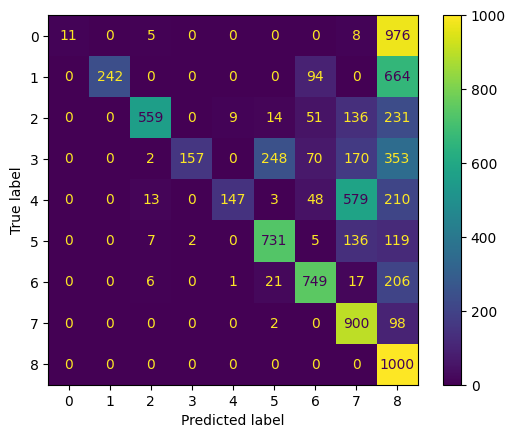

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
1375/1375 [==============================] - 3s 2ms/step
Epoch 1/100
375/375 [==============================] - 4s 8ms/step - loss: 0.0017 - accuracy: 0.9930 - val_loss: 0.0969 - val_accuracy: 0.5214
Epoch 2/100
375/375 [==============================] - 3s 7ms/step - loss: 1.0777e-04 - accuracy: 0.9999 - val_loss: 0.0999 - val_accuracy: 0.5037
Epoch 3/100
375/375 [==============================] - 3s 7ms/step - loss: 6.8456e-05 - accuracy: 0.9999 - val_loss: 0.1035 - val_accuracy: 0.4860
Epoch 4/100
375/375 [==============================] - 3s 7ms/step - loss: 5.0245e-05 - accuracy: 1.0000 - val_loss: 0.1054 - val_accuracy: 0.4769
Epoch 5/100
375/375 [==============================] - 3s 7ms/step - loss: 3.8386e-05 - accuracy: 0.9999 - val_loss: 0.1062 - val_accuracy: 0.4712
Epoch 6/100
375/375

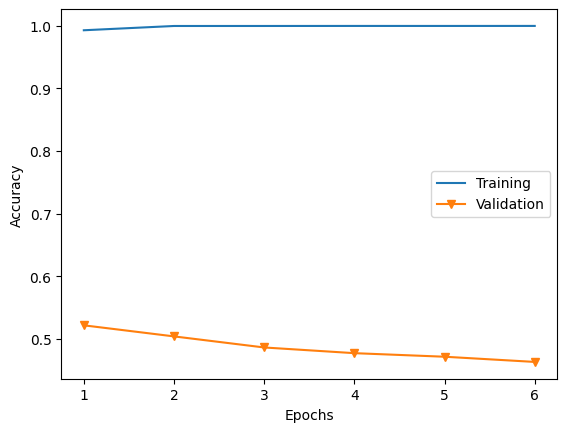

Epoch 1/10
2/2 [==============================] - 4s 4s/step - loss: 0.0056 - recon_loss: 0.0036 - kl_loss: 0.0086 - val_loss: 0.0477 - val_recon_loss: 0.0395 - val_kl_loss: 0.0328 - decoder_accuracy: 0.9999
Epoch 2/10
2/2 [==============================] - 4s 4s/step - loss: 0.0057 - recon_loss: 0.0034 - kl_loss: 0.0090 - val_loss: 0.0472 - val_recon_loss: 0.0395 - val_kl_loss: 0.0309 - decoder_accuracy: 0.9994
Epoch 3/10
2/2 [==============================] - 4s 4s/step - loss: 0.0054 - recon_loss: 0.0032 - kl_loss: 0.0088 - val_loss: 0.0457 - val_recon_loss: 0.0385 - val_kl_loss: 0.0288 - decoder_accuracy: 0.9889
Epoch 4/10
2/2 [==============================] - 4s 4s/step - loss: 0.0057 - recon_loss: 0.0036 - kl_loss: 0.0086 - val_loss: 0.0437 - val_recon_loss: 0.0370 - val_kl_loss: 0.0267 - decoder_accuracy: 0.9852
Epoch 5/10
2/2 [==============================] - 4s 4s/step - loss: 0.0064 - recon_loss: 0.0043 - kl_loss: 0.0082 - val_loss: 0.0433 - val_recon_loss: 0.0370 - val_kl_

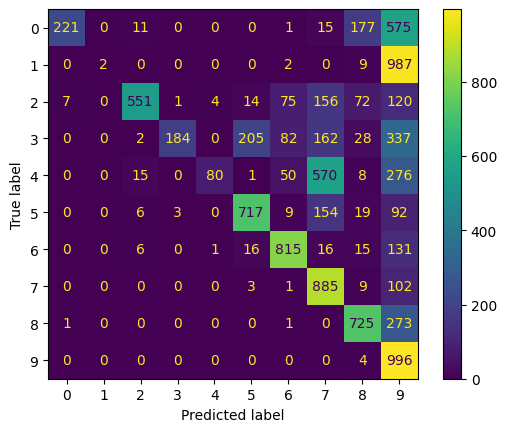

---------------------------------------------------------------------------



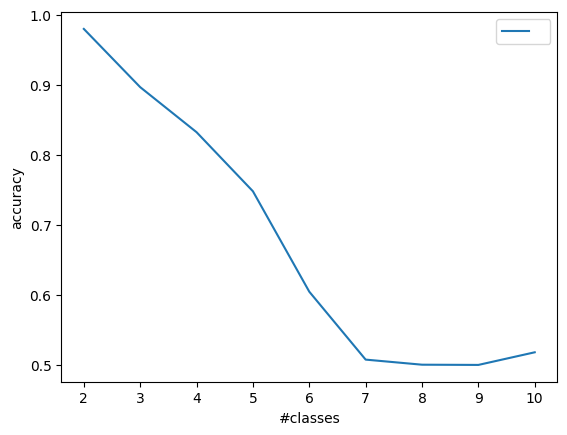

In [3]:
from tensorflow.keras import optimizers

from masked_loss import MaskedLoss
from model import get_compile_args


acc_list9 = continually_learn(
    class_num=CLASS_NUM, 
    load_dataset_fn=load_cifar10, 
    load_dataset_fn_kwargs={"onehot_labels": True}, 
    remove_prev_classes=True, 
    keep_same_model=True, 
    tuned_model_path=TUNED_DNN_MODEL_PATH, 
    compile_args=get_compile_args(
        optimizer=optimizers.Adam(learning_rate=5e-5), 
        loss=MaskedLoss()
    ), 
    batch_size=BATCH_SIZE, 
    epochs=EPOCHS, 
    use_vae=True,
)

## Conclusion

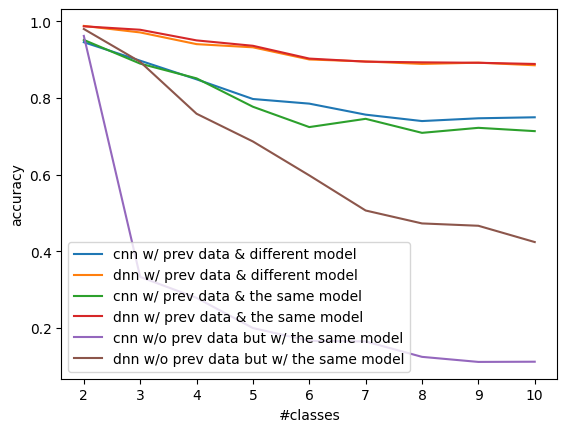

In [9]:
CL_plot(CLASS_NUM, 
    [
    (acc_list1, "cnn w/ prev data & different model"), 
    (acc_list2, "dnn w/ prev data & different model"), 
    (acc_list3, "cnn w/ prev data & the same model"), 
    (acc_list4, "dnn w/ prev data & the same model"), 
    (acc_list5, "cnn w/o prev data but w/ the same model"), 
    (acc_list6, "dnn w/o prev data but w/ the same model"), 
    ]
)